# NammaFlow — Exploratory Data Analysis

## Phase 2: Demand, Funnel, Operations & Driver Intelligence

### Project
**NammaFlow: Urban Mobility Demand & Supply Intelligence for Namma Yatri — Bengaluru**

### Objective

The purpose of Phase 2 is to explore the cleaned Namma Yatri operational datasets produced during Phase 1 and identify meaningful mobility patterns across time, vehicle categories, booking behaviour, wards, cancellations, conversion funnels, and driver supply.

The analysis will focus on answering questions such as:

- When is ride demand highest and lowest?
- How does demand change by hour and date?
- Which vehicle and trip categories generate the most bookings and completed rides?
- Where does the search-to-ride funnel lose the most users?
- What are the major causes and patterns of ride cancellations?
- Which Bengaluru wards experience high demand or weak conversion?
- Where do potential driver supply-demand mismatches exist?
- What operational insights can help improve ride fulfilment and driver allocation?

The findings from this phase will later support feature engineering, machine learning, supply-demand intelligence, and dashboard development.

In [1]:
!git clone https://github.com/Narasimhan15/NammaFlow.git

Cloning into 'NammaFlow'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 34 (delta 7), reused 20 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 697.33 KiB | 4.28 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [2]:
%cd /content/NammaFlow

/content/NammaFlow


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
!ls -lh data/processed/

total 352K
-rw-r--r-- 1 root root  30K Oct  4 11:26 city_demand_bengaluru.csv
-rw-r--r-- 1 root root  50K Oct  4 11:26 city_operations_bengaluru.csv
-rw-r--r-- 1 root root  100 Oct  4 11:26 date_coverage.csv
-rw-r--r-- 1 root root  12K Oct  4 11:26 driver_supply_clean.csv
-rw-r--r-- 1 root root 249K Oct  4 11:26 ward_funnel_clean.csv


---

## 1. Environment Setup & Processed Data Loading

Phase 1 completed the structural validation, cleaning, and preparation of the raw Namma Yatri datasets.

Therefore, Phase 2 uses the processed datasets directly rather than repeating the raw-data cleaning workflow.

### Processed datasets

- `city_demand_bengaluru.csv` — city-level demand and search behaviour
- `city_operations_bengaluru.csv` — vehicle-level bookings, rides, cancellations and earnings
- `ward_funnel_clean.csv` — ward-level search and conversion funnel
- `driver_supply_clean.csv` — ward-level driver supply information
- `date_coverage.csv` — dataset date coverage information

This separation keeps the project modular and ensures that exploratory analysis is reproducible without duplicating Phase 1 preprocessing.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
city_demand = pd.read_csv("data/processed/city_demand_bengaluru.csv")
city_operations = pd.read_csv("data/processed/city_operations_bengaluru.csv")
ward_funnel = pd.read_csv("data/processed/ward_funnel_clean.csv")
driver_supply = pd.read_csv("data/processed/driver_supply_clean.csv")
date_coverage = pd.read_csv("data/processed/date_coverage.csv")

print("Processed datasets loaded successfully.")

Processed datasets loaded successfully.


In [7]:
print("city_demand shape     :", city_demand.shape)
print("city_operations shape :", city_operations.shape)
print("ward_funnel shape     :", ward_funnel.shape)
print("driver_supply shape   :", driver_supply.shape)
print("date_coverage shape   :", date_coverage.shape)

city_demand shape     : (306, 24)
city_operations shape : (505, 24)
ward_funnel shape     : (2928, 29)
driver_supply shape   : (486, 6)
date_coverage shape   : (3, 3)


---

## 2. Phase 2 : Data Integrity Validation

Before beginning exploratory analysis, the processed datasets are revalidated to ensure that the Phase 1 outputs were loaded correctly.

The validation checks:

- Dataset dimensions
- Missing values
- Duplicate rows
- Date coverage
- Data types

This step is not intended to repeat Phase 1 cleaning. It acts as a lightweight validation layer before calculating business KPIs and performing exploratory analysis.

In [8]:
datasets = {
    "City Demand": city_demand,
    "City Operations": city_operations,
    "Ward Funnel": ward_funnel,
    "Driver Supply": driver_supply
}

integrity_summary = []

for name, df in datasets.items():
    integrity_summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Duplicate Rows": df.duplicated().sum(),
        "Missing Values": df.isnull().sum().sum()
    })

integrity_summary = pd.DataFrame(integrity_summary)

integrity_summary

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,City Demand,306,24,0,306
1,City Operations,505,24,0,1091
2,Ward Funnel,2928,29,0,15533
3,Driver Supply,486,6,0,0


Missing values by columns

In [9]:
for name, df in datasets.items():

    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")

    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) == 0:
        print("No missing values.")
    else:
        display(
            pd.DataFrame({
                "Missing_Count": missing,
                "Missing_%": (missing / len(df) * 100).round(2)
            })
        )


City Demand


,Missing_Count,Missing_%
bkng_cancel_rate,306,100.0



City Operations


,Missing_Count,Missing_%
cnvr_rate,505,100.00
q_accept_rate,505,100.00
bkng_cancel_rate,81,16.04



Ward Funnel


,Missing_Count,Missing_%
q_to_bkng_rate,2617,89.38
q_accept_rate,2615,89.31
e_to_q_srch_rate,2614,89.28
srch_to_e_rate,2614,89.28
cnvr_rate,2614,89.28
bkng_cancel_rate,2459,83.98



Driver Supply
No missing values.


### Missing-Value Observation

Missing values are concentrated primarily in derived rate columns rather than the underlying activity-count columns.

These values are not automatically imputed or removed because a missing rate can occur when the metric is not applicable or when the denominator required to calculate the rate is zero.

The underlying numerator and denominator columns will therefore be validated before interpreting these rate fields.

In [10]:
date_coverage

,date,hours_available,day_status
0,2026-05-03,24,Complete
1,2026-05-09,24,Complete
2,2026-05-10,16,Partial


### Date-Coverage Observation

The city-level dataset contains three observed dates:

- **2026-05-03:** 24 hours — Complete
- **2026-05-09:** 24 hours — Complete
- **2026-05-10:** 16 hours — Partial

Because 2026-05-10 contains only 16 observed hours, its raw daily totals are not directly comparable with the two complete 24-hour dates.

Where date-level comparisons are required, the analysis will either:

1. compare equivalent observed hours across dates, or
2. use normalized metrics such as activity per observed hour.

This prevents the partial day from being incorrectly interpreted as lower demand or weaker operational performance.

In [11]:
print("CITY DEMAND")
print("-" * 50)

print("Total bookings:", city_demand["booking"].sum())
print("Total cancellations:", city_demand["cancel_ride"].sum())
print("Non-null booking cancellation rate:",
      city_demand["bkng_cancel_rate"].notna().sum())


print("\nCITY OPERATIONS")
print("-" * 50)

print("Total searches:", city_operations["srch_rqst"].sum())
print("Total quote searches:", city_operations["srch_fr_q"].sum())
print("Total bookings:", city_operations["booking"].sum())

print("Non-null conversion rate:",
      city_operations["cnvr_rate"].notna().sum())

print("Non-null quote acceptance rate:",
      city_operations["q_accept_rate"].notna().sum())

print("Non-null booking cancellation rate:",
      city_operations["bkng_cancel_rate"].notna().sum())

CITY DEMAND
--------------------------------------------------
Total bookings: 0
Total cancellations: 0
Non-null booking cancellation rate: 0

CITY OPERATIONS
--------------------------------------------------
Total searches: 0
Total quote searches: 0
Total bookings: 442586
Non-null conversion rate: 0
Non-null quote acceptance rate: 0
Non-null booking cancellation rate: 424


This code will tell us whether those rate columns are simply unavailable for those particular row types rather than representing genuinely missing operational records.

### Structural Missingness Validation

The city-level processed datasets represent separate analytical layers.

- `city_demand` contains demand/search activity and does not contain active booking or cancellation metrics.
- `city_operations` contains booking and downstream operational activity but does not contain active search or quote-search metrics.

Therefore, missing values in derived rate fields such as `cnvr_rate`, `q_accept_rate`, and `bkng_cancel_rate` are primarily structural rather than conventional missing-data problems.

These fields will not be imputed. Relevant KPIs will instead be calculated directly from their appropriate underlying activity columns.

In [12]:
ward_funnel.columns.tolist()

['ward_num',
 'srch_fr_e',
 'srch_which_got_e',
 'srch_fr_q',
 'srch_which_got_q',
 'booking',
 'ongng_ride',
 'done_ride',
 'rides',
 'cancel_ride',
 'drvr_cancel',
 'rider_cancel',
 'earning',
 'dist',
 'avg_dist_pr_trip',
 'avg_fare',
 'trip_category',
 'vehicle_type',
 'srch_fr_q_variant',
 'srch_which_got_q_variant',
 'is_bike',
 'is_cab',
 'is_auto',
 'srch_to_e_rate',
 'e_to_q_srch_rate',
 'q_accept_rate',
 'q_to_bkng_rate',
 'cnvr_rate',
 'bkng_cancel_rate']

**Actual active city metrics**

In [13]:
print("CITY DEMAND — ACTIVE METRICS")
print("-" * 50)
print("Search requests :", city_demand["srch_rqst"].sum())
print("Searches with E :", city_demand["srch_which_got_e"].sum())
print("Searches for Q  :", city_demand["srch_fr_q"].sum())
print("Searches with Q :", city_demand["srch_which_got_q"].sum())

print("\nCITY OPERATIONS — ACTIVE METRICS")
print("-" * 50)
print("Bookings        :", city_operations["booking"].sum())
print("Rides           :", city_operations["rides"].sum())
print("Completed rides :", city_operations["done_ride"].sum())
print("Cancelled rides :", city_operations["cancel_ride"].sum())
print("Driver cancels  :", city_operations["drvr_cancel"].sum())
print("Rider cancels   :", city_operations["rider_cancel"].sum())
print("Earnings        :", city_operations["earning"].sum())

CITY DEMAND — ACTIVE METRICS
--------------------------------------------------
Search requests : 1151407
Searches with E : 1146319
Searches for Q  : 837087
Searches with Q : 464824

CITY OPERATIONS — ACTIVE METRICS
--------------------------------------------------
Bookings        : 442586
Rides           : 440111
Completed rides : 282542
Cancelled rides : 148641
Driver cancels  : 74270
Rider cancels   : 73747
Earnings        : 53494253


One thing we should notice already: **completed rides + cancelled rides** does not equal **total rides**. We'll preserve that difference rather than making assumptions; it may represent rides in another/in-progress state. Similarly, **driver + rider cancellations** do not account for every **cancelled ride**.

---

## 3. KPI Framework & Baseline Performance

Before performing detailed exploratory analysis, the core NammaFlow KPIs are defined using the appropriate processed dataset.

### KPI Source Rules

| KPI Category | Dataset | Reason |
|---|---|---|
| Search Demand | `city_demand` | Contains city-level search activity |
| E-stage / Q-stage Funnel | `city_demand` | Contains active search funnel counts |
| Bookings | `city_operations` | Contains operational booking activity |
| Rides | `city_operations` | Contains ride activity |
| Completed Rides | `city_operations` | Contains completed-trip counts |
| Cancellations | `city_operations` | Contains total, driver and rider cancellations |
| Earnings | `city_operations` | Contains operational earnings |
| Ward Funnel | `ward_funnel` | Used for geographic funnel analysis |
| Driver Supply | `driver_supply` | Used for ward-level driver availability |

### Important Aggregation Rule

The demand and operations datasets represent different analytical layers.

Search metrics and operational metrics must therefore be aggregated from their respective datasets rather than summing overlapping vehicle-level `"All"` and Auto/Cab rows.

This prevents double counting and preserves the intended structure of the source data.

**Check operational reconciliation**

In [14]:
booking_to_ride_gap = (
    city_operations["booking"].sum()
    - city_operations["rides"].sum()
)

ride_status_gap = (
    city_operations["rides"].sum()
    - city_operations["done_ride"].sum()
    - city_operations["cancel_ride"].sum()
)

cancel_reason_gap = (
    city_operations["cancel_ride"].sum()
    - city_operations["drvr_cancel"].sum()
    - city_operations["rider_cancel"].sum()
)

print("Booking → ride gap              :", booking_to_ride_gap)
print("Ride status residual            :", ride_status_gap)
print("Unclassified cancellation gap   :", cancel_reason_gap)

Booking → ride gap              : 2475
Ride status residual            : 8928
Unclassified cancellation gap   : 624


**Building the baseline KPI Table**

In [15]:
total_searches = city_demand["srch_rqst"].sum()
searches_with_e = city_demand["srch_which_got_e"].sum()
searches_for_q = city_demand["srch_fr_q"].sum()
searches_with_q = city_demand["srch_which_got_q"].sum()

total_bookings = city_operations["booking"].sum()
total_rides = city_operations["rides"].sum()
completed_rides = city_operations["done_ride"].sum()
cancelled_rides = city_operations["cancel_ride"].sum()

driver_cancels = city_operations["drvr_cancel"].sum()
rider_cancels = city_operations["rider_cancel"].sum()

total_earnings = city_operations["earning"].sum()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Search Requests",
        "Searches Reaching E-stage",
        "Searches Requesting Q-stage",
        "Searches Receiving Q-stage",
        "Bookings",
        "Rides",
        "Completed Rides",
        "Cancelled Rides",
        "Driver Cancellations",
        "Rider Cancellations",
        "Total Earnings"
    ],
    "Value": [
        total_searches,
        searches_with_e,
        searches_for_q,
        searches_with_q,
        total_bookings,
        total_rides,
        completed_rides,
        cancelled_rides,
        driver_cancels,
        rider_cancels,
        total_earnings
    ]
})

kpi_summary

,KPI,Value
0,Total Search Requests,1151407
1,Searches Reaching E-stage,1146319
2,Searches Requesting Q-stage,837087
3,Searches Receiving Q-stage,464824
4,Bookings,442586
5,Rides,440111
6,Completed Rides,282542
7,Cancelled Rides,148641
8,Driver Cancellations,74270
9,Rider Cancellations,73747


**Calculate business rates**

In [16]:
baseline_rates = pd.DataFrame({
    "Metric": [
        "Search → E-stage Rate",
        "Q-stage Success Rate",
        "Search → Booking Conversion",
        "Booking → Ride Rate",
        "Booking Completion Rate",
        "Booking Cancellation Rate",
        "Driver Share of Cancellations",
        "Rider Share of Cancellations",
        "Average Earnings per Completed Ride"
    ],
    "Value": [
        searches_with_e / total_searches * 100,
        searches_with_q / searches_for_q * 100,
        total_bookings / total_searches * 100,
        total_rides / total_bookings * 100,
        completed_rides / total_bookings * 100,
        cancelled_rides / total_bookings * 100,
        driver_cancels / cancelled_rides * 100,
        rider_cancels / cancelled_rides * 100,
        total_earnings / completed_rides
    ]
})

baseline_rates["Value"] = baseline_rates["Value"].round(2)

baseline_rates

,Metric,Value
0,Search → E-stage Rate,99.56
1,Q-stage Success Rate,55.53
2,Search → Booking Conversion,38.44
3,Booking → Ride Rate,99.44
4,Booking Completion Rate,63.84
5,Booking Cancellation Rate,33.58
6,Driver Share of Cancellations,49.97
7,Rider Share of Cancellations,49.61
8,Average Earnings per Completed Ride,189.33


1,151,407 search requests

442,586 bookings

440,111 rides

282,542 completed rides

148,641 cancellations

₹53,494,253 earnings

Reconciliation checks:

Booking → ride gap            : 2,475

Ride status residual          : 8,928

Unclassified cancellation gap : 624


In the Namma Yatri funnel fields, E and Q appear to represent intermediate stages in the rider search flow. Based on the column names and the platform booking flow, the practical interpretation is:
- E-stage = Estimate stage
  The rider searches for a trip and the system is able to return a fare/ride estimate.
- Q-stage = Quote stage
  The rider proceeds further and requests/receives an actual quote or offer that can lead toward booking.

### Baseline KPI Insights

The baseline performance metrics reveal several important patterns in the Namma Yatri mobility funnel.

1. **Search availability is very strong**
   - 99.56% of search requests reached the E-stage.
   - This suggests that the initial search stage is not the primary bottleneck.

2. **The largest early-stage funnel loss occurs around the Q-stage**
   - Only 55.53% of searches requesting the Q-stage successfully received it.
   - This indicates a substantial drop between quote/request initiation and successful quote availability.

3. **Overall search-to-booking conversion is 38.44%**
   - Fewer than four out of every ten search requests ultimately became bookings.
   - Later analysis will investigate whether this varies by hour, vehicle type, trip category, and ward.

4. **Bookings almost always progress into a ride record**
   - The booking-to-ride rate is 99.44%.
   - Only 2,475 bookings did not appear as ride records in the observed data.

5. **Ride completion represents 63.84% of bookings**
   - Approximately one-third of bookings were cancelled.
   - The booking cancellation rate is 33.58%, making cancellations an important operational area for further investigation.

6. **Driver and rider cancellations contribute almost equally**
   - Driver cancellations account for approximately 49.97% of total cancellations.
   - Rider cancellations account for approximately 49.61%.
   - A small residual of 624 cancellations is not classified into either category.

7. **Not every ride record is classified as completed or cancelled**
   - 8,928 ride records remain outside the completed and cancelled categories.
   - These records will be treated as an unresolved ride-status residual unless additional source information establishes their exact meaning.

8. **Observed earnings per completed ride are approximately ₹189.33**
   - This ratio provides an initial operating benchmark and will later be compared across vehicle and trip categories.

---

## 4. Time-Based Demand Analysis

Understanding when ride demand occurs is essential for driver allocation, supply planning, and peak-hour operations.

Because one observed date (`2026-05-10`) contains only 16 hours, raw search totals by hour could be biased toward hours that appear across more observed dates.

Therefore, the analysis first aggregates demand at the **date-hour level** and then calculates the **average search demand per observed day for each hour**.

This provides a fair comparison between hours despite incomplete date coverage.

**Pre date-hour demand**

In [17]:
# Convert date to datetime for reliable time analysis
city_demand["date"] = pd.to_datetime(city_demand["date"])

# Aggregate all demand rows into one record per date and hour
city_demand_hourly = (
    city_demand
    .groupby(["date", "hour"], as_index=False)
    .agg(
        search_requests=("srch_rqst", "sum"),
        searches_with_e=("srch_which_got_e", "sum"),
        searches_for_q=("srch_fr_q", "sum"),
        searches_with_q=("srch_which_got_q", "sum")
    )
)

print("Date-hour rows:", city_demand_hourly.shape[0])
print("Unique dates:", city_demand_hourly["date"].nunique())
print("Unique hours:", sorted(city_demand_hourly["hour"].unique()))

city_demand_hourly.head()

Date-hour rows: 64
Unique dates: 3
Unique hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,date,hour,search_requests,searches_with_e,searches_for_q,searches_with_q
0,2026-05-03,0,5205,5191,3826,2431
1,2026-05-03,1,4282,4253,3440,1795
2,2026-05-03,2,1395,1387,987,761
3,2026-05-03,3,1228,1210,798,563
4,2026-05-03,4,2344,2337,1454,974


**How many dates contribute to each hour**

In [18]:
hour_coverage = (
    city_demand_hourly
    .groupby("hour")
    .agg(
        observed_days=("date", "nunique"),
        total_searches=("search_requests", "sum"),
        average_searches=("search_requests", "mean")
    )
    .reset_index()
)

hour_coverage

,hour,observed_days,total_searches,average_searches
0,0,3,15434,5144.666667
1,1,3,12166,4055.333333
2,2,3,4091,1363.666667
3,3,3,3666,1222.000000
4,4,3,6912,2304.000000
5,5,3,12967,4322.333333
6,6,3,19626,6542.000000
7,7,3,26776,8925.333333
8,8,3,38941,12980.333333
9,9,3,51261,17087.000000


The coverage table confirms:
- Hours 00:00–15:00 → 3 observed days
- Hours 16:00–23:00 → 2 observed days

So using average_searches instead of raw total_searches is the correct approach.

From the table, we can already see a strong pattern: demand is extremely low around 02:00–04:00, rises steadily through the morning, and reaches its strongest level around 18:00–19:00. In particular, hour 18 averages about 45,379 searches per observed day, while hour 3 averages only about 1,222.

**First real visualization -- 24hrs demand curve**

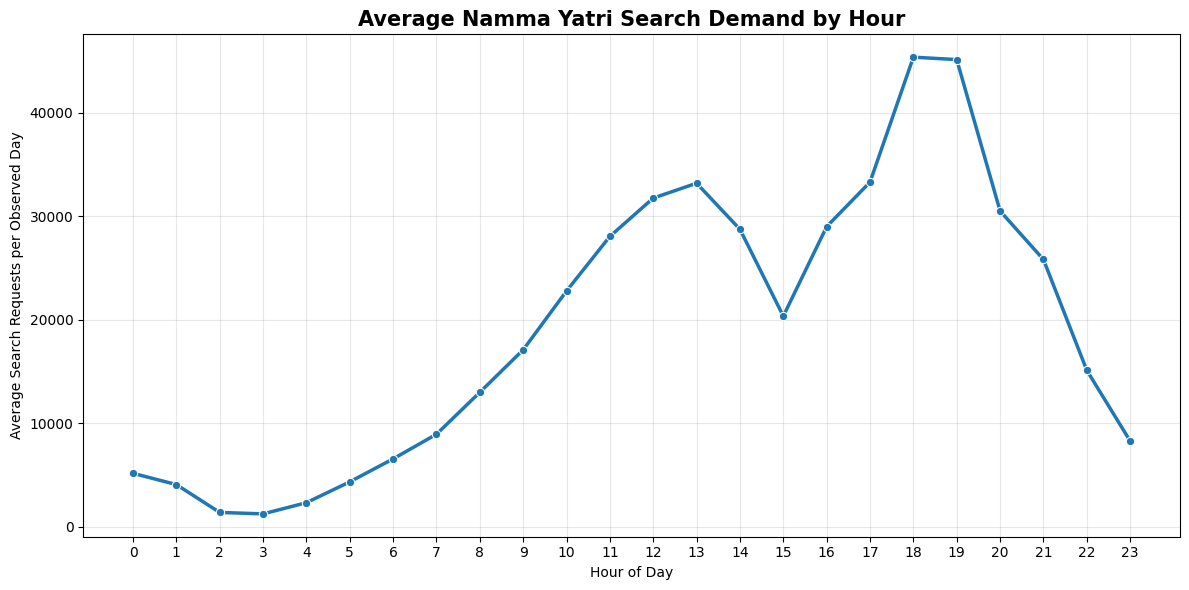

In [19]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hour_coverage,
    x="hour",
    y="average_searches",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Average Namma Yatri Search Demand by Hour",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Search Requests per Observed Day")

plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

This is important because we don't want to identify peak hours just by eyeballing the chart.

In [20]:
peak_hours = (
    hour_coverage
    .sort_values("average_searches", ascending=False)
    [["hour", "observed_days", "average_searches"]]
    .head(5)
)

low_demand_hours = (
    hour_coverage
    .sort_values("average_searches", ascending=True)
    [["hour", "observed_days", "average_searches"]]
    .head(5)
)

print("TOP 5 DEMAND HOURS")
display(peak_hours)

print("\nLOWEST 5 DEMAND HOURS")
display(low_demand_hours)

TOP 5 DEMAND HOURS


,hour,observed_days,average_searches
18,18,2,45378.500000
19,19,2,45143.500000
17,17,2,33298.000000
13,13,3,33190.666667
12,12,3,31755.333333



LOWEST 5 DEMAND HOURS


,hour,observed_days,average_searches
3,3,3,1222.000000
2,2,3,1363.666667
4,4,3,2304.000000
1,1,3,4055.333333
5,5,3,4322.333333


So the observed demand at 18:00 is roughly 37× the demand at 03:00.

One important limitation: the evening hours 16:00–23:00 are based on only 2 observed dates, while 00:00–15:00 have 3 dates. Therefore, we can describe 18:00–19:00 as the strongest evening peak in the observed sample, but we should not generalize it to all Bengaluru days yet.

### Hourly Demand Insights

The hourly demand curve reveals a strong time-of-day pattern in Namma Yatri search activity.

- Demand is lowest during the early-morning period, particularly between **02:00 and 04:00**.
- Search activity begins increasing steadily from approximately **05:00–06:00**.
- A strong daytime demand window appears around **12:00–13:00**.
- The largest observed demand peak occurs during the evening period at **18:00–19:00**.
- The highest observed hour is **18:00**, with approximately **45.4K average search requests per observed day**.
- By comparison, **03:00** records only about **1.2K average searches**, making peak observed demand roughly **37 times larger** than the lowest-demand hour.
- Demand falls rapidly again after approximately **20:00**.

### Operational Interpretation

The observed pattern suggests that driver availability and supply planning may be especially important during the evening demand window.

However, the evening hours from 16:00 onward are represented by only two observed dates, while earlier hours contain three dates. Therefore, these findings should be treated as patterns within the available sample rather than universal Bengaluru demand behaviour.

**Q. Does high demand also create a funnel problem?**

Having lots of searches at 6–7 PM is useful, but what if riders are searching and failing to progress through the E/Q stages?

In [21]:
hourly_funnel = (
    city_demand_hourly
    .groupby("hour", as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        search_requests=("search_requests", "sum"),
        searches_with_e=("searches_with_e", "sum"),
        searches_for_q=("searches_for_q", "sum"),
        searches_with_q=("searches_with_q", "sum")
    )
)

hourly_funnel["e_stage_rate"] = (
    hourly_funnel["searches_with_e"]
    / hourly_funnel["search_requests"] * 100
)

hourly_funnel["q_request_rate"] = (
    hourly_funnel["searches_for_q"]
    / hourly_funnel["search_requests"] * 100
)

hourly_funnel["q_success_rate"] = (
    hourly_funnel["searches_with_q"]
    / hourly_funnel["searches_for_q"] * 100
)

hourly_funnel[
    [
        "hour",
        "observed_days",
        "search_requests",
        "e_stage_rate",
        "q_request_rate",
        "q_success_rate"
    ]
].round(2)

,hour,observed_days,search_requests,e_stage_rate,q_request_rate,q_success_rate
0,0,3,15434,99.60,73.44,66.00
1,1,3,12166,99.55,79.40,54.24
2,2,3,4091,99.56,67.64,79.29
3,3,3,3666,99.10,64.43,75.06
4,4,3,6912,99.64,60.21,67.47
5,5,3,12967,99.67,69.30,52.15
6,6,3,19626,99.72,68.23,58.66
7,7,3,26776,99.69,66.26,67.34
8,8,3,38941,99.65,68.43,67.35
9,9,3,51261,99.17,67.83,67.08


**Demand peak -> Q stage success**

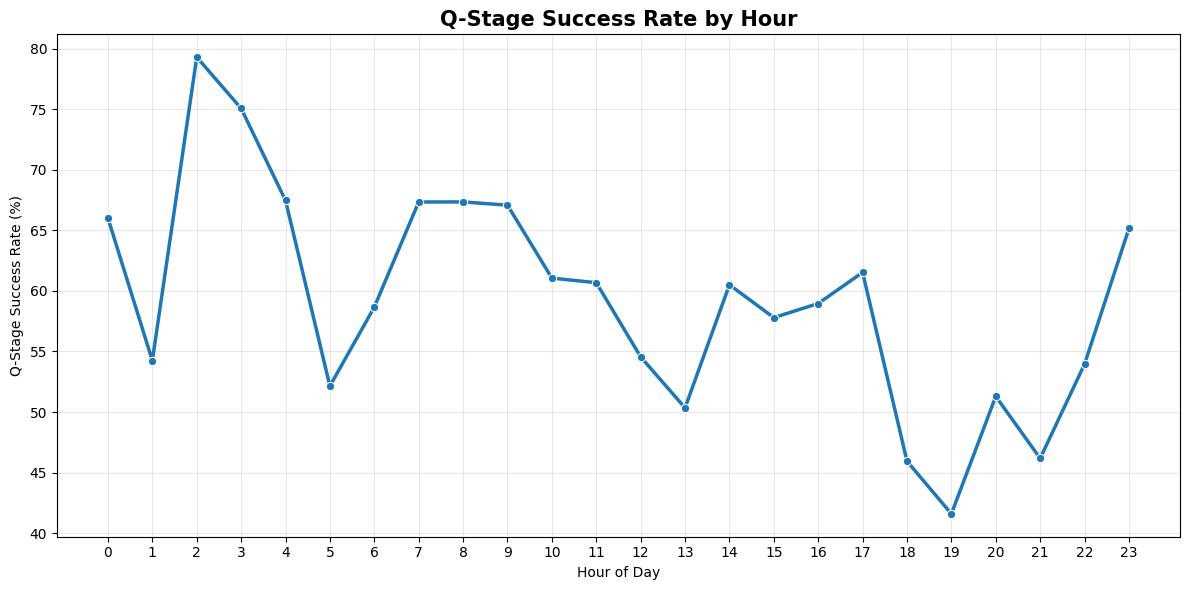

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_funnel,
    x="hour",
    y="q_success_rate",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Q-Stage Success Rate by Hour",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Q-Stage Success Rate (%)")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Evening demand surges

        ↓

Search system still works
(E-stage remains ~99%)

        ↓

Q-stage availability falls

        ↓
        
More riders may struggle to progress
toward a successful booking.

But we should phrase this carefully: this shows an association in our observed sample, not proof that high demand causes the Q-stage decline. Also, 18:00–23:00 contains only two observed dates.

### Demand vs Q-Stage Performance Insight

The hourly funnel analysis reveals an important contrast between initial search availability and later-stage service availability.

- The **E-stage rate remains consistently close to 99% throughout the day**, indicating that the initial search stage remains highly available even during periods of heavy demand.
- However, the **Q-stage success rate varies substantially by hour**.
- During the largest observed evening demand peak:
  - **18:00:** Q-stage success falls to approximately **45.95%**
  - **19:00:** Q-stage success falls further to approximately **41.60%**
- The 19:00 hour records the **lowest observed Q-stage success rate** despite being one of the highest-demand periods.
- By comparison, several low-demand early-morning hours achieve Q-stage success rates above 65–75%.

### Operational Interpretation

This pattern suggests a potential service-availability bottleneck during evening peak demand.

The system appears capable of processing initial rider searches, but a substantially smaller proportion of riders successfully progress through the Q-stage when demand reaches its evening peak.

This could indicate a mismatch between rider demand and available service capacity during peak hours and will later be investigated using booking, cancellation, ward-level funnel, and driver-supply information.

Because the evening hours are represented by only two observed dates, this result should be interpreted as an observed sample pattern rather than a universal Bengaluru behaviour.

In [23]:
demand_q_analysis = (
    hour_coverage[
        ["hour", "observed_days", "average_searches"]
    ]
    .merge(
        hourly_funnel[
            ["hour", "q_success_rate", "e_stage_rate"]
        ],
        on="hour",
        how="left"
    )
)

demand_q_analysis = demand_q_analysis.round(2)

demand_q_analysis.sort_values(
    "average_searches",
    ascending=False
).head(10)

,hour,observed_days,average_searches,q_success_rate,e_stage_rate
18,18,2,45378.50,45.95,99.54
19,19,2,45143.50,41.60,99.73
17,17,2,33298.00,61.53,99.81
13,13,3,33190.67,50.35,99.52
12,12,3,31755.33,54.56,99.69
20,20,2,30508.50,51.29,99.31
16,16,2,28995.00,58.96,99.73
14,14,3,28733.67,60.50,99.45
11,11,3,28052.00,60.68,99.50
21,21,2,25818.00,46.18,99.50


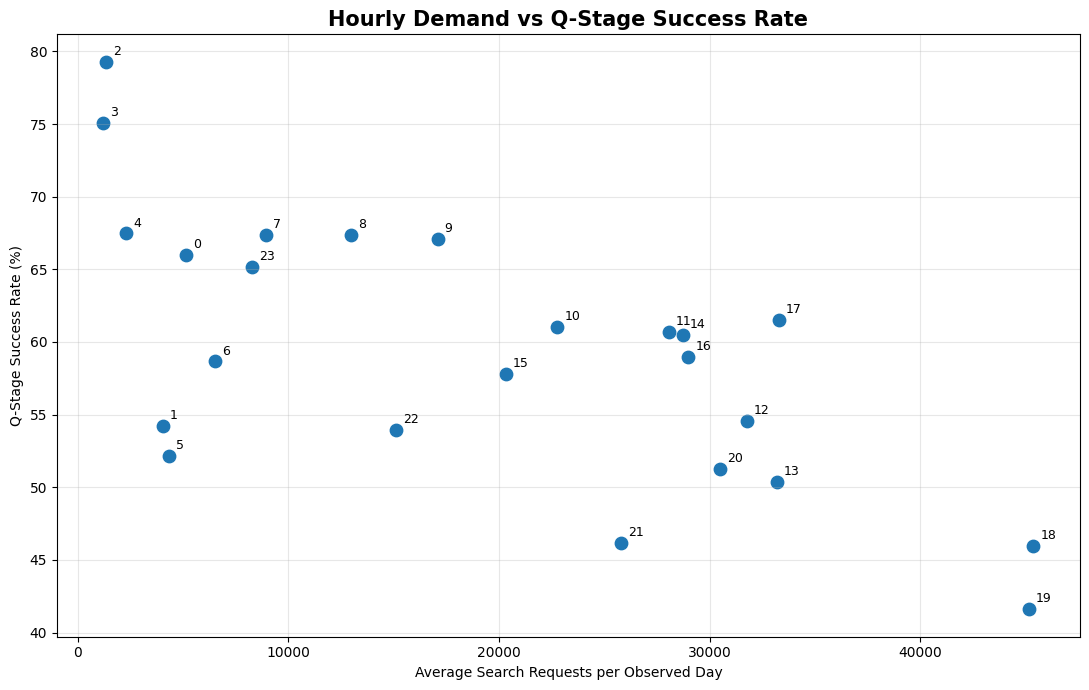

In [24]:
plt.figure(figsize=(11, 7))

plt.scatter(
    demand_q_analysis["average_searches"],
    demand_q_analysis["q_success_rate"],
    s=80
)

for _, row in demand_q_analysis.iterrows():
    plt.annotate(
        int(row["hour"]),
        (row["average_searches"], row["q_success_rate"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(
    "Hourly Demand vs Q-Stage Success Rate",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Search Requests per Observed Day")
plt.ylabel("Q-Stage Success Rate (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Each dot will represent **one hour**, and the number beside it is the hour.

### Demand–Q-Stage Relationship

The combined demand and Q-stage analysis highlights a possible peak-hour service-capacity issue.

- The two highest-demand hours, **18:00 and 19:00**, appear in the high-demand / low-Q-stage-success region of the scatter plot.
- **18:00** averages approximately **45.4K searches** with a Q-stage success rate of **45.95%**.
- **19:00** averages approximately **45.1K searches** while Q-stage success falls to **41.60%**, the lowest observed hourly rate.
- Several low-demand hours achieve considerably higher Q-stage success rates.

This suggests that high-demand periods may experience greater difficulty progressing riders through the Q-stage.

The relationship is observational rather than causal and is based on a limited number of observed dates.

**Q. Once riders actually book, which hours have the highest completion and cancellation problems?**

---

## 5. Hourly Booking, Completion & Cancellation Analysis

After examining search demand and Q-stage performance, the next step is to evaluate downstream operational outcomes.

The analysis focuses on:

- Booking volume
- Completed rides
- Cancelled rides
- Booking completion rate
- Booking cancellation rate
- Driver vs rider cancellations
- Earnings

As with demand analysis, hourly comparisons account for the partial third day by aggregating activity at the date-hour level before comparing hours.

**date-hour operations data**

In [25]:
city_operations["date"] = pd.to_datetime(city_operations["date"])

operations_date_hour = (
    city_operations
    .groupby(["date", "hour"], as_index=False)
    .agg(
        bookings=("booking", "sum"),
        rides=("rides", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        driver_cancels=("drvr_cancel", "sum"),
        rider_cancels=("rider_cancel", "sum"),
        earnings=("earning", "sum")
    )
)

print("Date-hour operational rows:", operations_date_hour.shape[0])
print("Unique dates:", operations_date_hour["date"].nunique())
print("Unique hours:", sorted(operations_date_hour["hour"].unique()))

operations_date_hour.head()

Date-hour operational rows: 64
Unique dates: 3
Unique hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,date,hour,bookings,rides,completed_rides,cancelled_rides,driver_cancels,rider_cancels,earnings
0,2026-05-03,0,2111,1894,1053,1029,398,619,273863
1,2026-05-03,1,1448,1311,643,792,324,458,187316
2,2026-05-03,2,541,504,295,238,82,154,88032
3,2026-05-03,3,456,443,247,209,69,140,78437
4,2026-05-03,4,891,878,566,322,153,169,172835


**building hourly operational KPIs**

In [26]:
hourly_operations = (
    operations_date_hour
    .groupby("hour")
    .agg(
        observed_days=("date", "nunique"),
        total_bookings=("bookings", "sum"),
        total_rides=("rides", "sum"),
        total_completed=("completed_rides", "sum"),
        total_cancelled=("cancelled_rides", "sum"),
        driver_cancels=("driver_cancels", "sum"),
        rider_cancels=("rider_cancels", "sum"),
        total_earnings=("earnings", "sum"),
        average_bookings=("bookings", "mean")
    )
    .reset_index()
)

hourly_operations["completion_rate"] = (
    hourly_operations["total_completed"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations["cancellation_rate"] = (
    hourly_operations["total_cancelled"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations["booking_to_ride_rate"] = (
    hourly_operations["total_rides"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations[
    [
        "hour",
        "observed_days",
        "average_bookings",
        "completion_rate",
        "cancellation_rate",
        "booking_to_ride_rate"
    ]
].round(2)

,hour,observed_days,average_bookings,completion_rate,cancellation_rate,booking_to_ride_rate
0,0,3,2072.00,52.62,46.67,94.76
1,1,3,1398.00,50.43,48.78,94.11
2,2,3,518.33,56.66,42.77,96.14
3,3,3,460.00,56.96,42.83,98.12
4,4,3,834.33,62.29,37.51,99.00
5,5,3,1456.33,66.42,33.53,99.73
6,6,3,2499.33,68.44,31.52,99.80
7,7,3,3791.33,72.59,27.40,99.65
8,8,3,5703.00,72.26,27.55,99.67
9,9,3,7430.00,71.26,27.53,99.78


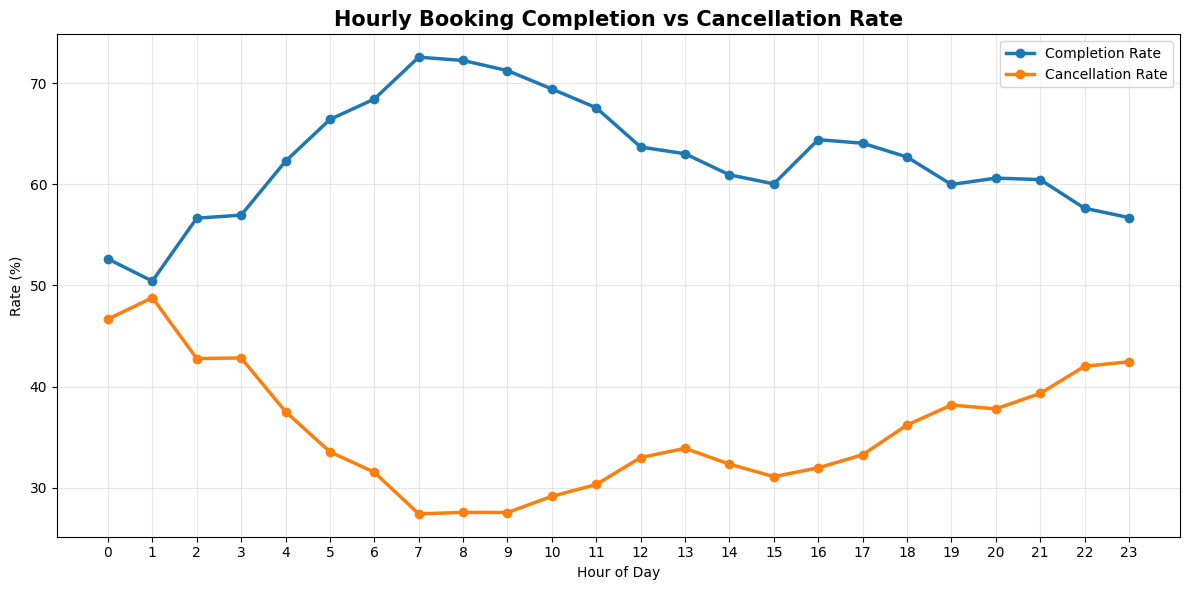

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_operations["hour"],
    hourly_operations["completion_rate"],
    marker="o",
    linewidth=2.5,
    label="Completion Rate"
)

plt.plot(
    hourly_operations["hour"],
    hourly_operations["cancellation_rate"],
    marker="o",
    linewidth=2.5,
    label="Cancellation Rate"
)

plt.title(
    "Hourly Booking Completion vs Cancellation Rate",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Rate (%)")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Hourly Operational Performance Insights

The booking-level analysis indicates that the evening demand pressure observed earlier continues into downstream ride operations.

- Booking volume increases substantially during the late afternoon and evening.
- The largest observed average booking volume occurs around **18:00**, with approximately **15.5K bookings per observed day**.
- During the morning period around **07:00–09:00**, booking completion rates exceed **71%**, while cancellation rates remain near **27%**.
- As evening demand increases, operational performance weakens:
  - **18:00:** 62.71% completion and 36.19% cancellation
  - **19:00:** 59.99% completion and 38.17% cancellation
  - **21:00:** 60.47% completion and 39.31% cancellation
- This suggests that the evening period experiences pressure not only at the Q-stage but also after riders successfully create bookings.

### Operational Interpretation

The combined funnel and booking patterns suggest a possible peak-hour capacity mismatch.

During evening demand peaks, riders are less likely to successfully progress through the Q-stage, and bookings that do occur experience lower completion and higher cancellation rates than several morning hours.

This makes the evening period an important candidate for later driver-supply and ward-level investigation.

The result remains observational and is based on a limited number of sampled dates.

One subtle point: completion rate + cancellation rate doesn't always equal 100%, because we already identified the unresolved ride-status residual. So we should not force these two lines to sum to 100%.

**Q. who is cancelling — drivers or riders?**

In [28]:
hourly_operations["driver_cancel_rate"] = (
    hourly_operations["driver_cancels"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations["rider_cancel_rate"] = (
    hourly_operations["rider_cancels"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations["unclassified_cancels"] = (
    hourly_operations["total_cancelled"]
    - hourly_operations["driver_cancels"]
    - hourly_operations["rider_cancels"]
)

cancel_by_hour = hourly_operations[
    [
        "hour",
        "average_bookings",
        "cancellation_rate",
        "driver_cancel_rate",
        "rider_cancel_rate",
        "unclassified_cancels"
    ]
].round(2)

cancel_by_hour

,hour,average_bookings,cancellation_rate,driver_cancel_rate,rider_cancel_rate,unclassified_cancels
0,0,2072.00,46.67,19.22,27.24,13
1,1,1398.00,48.78,19.96,28.54,12
2,2,518.33,42.77,12.60,30.03,2
3,3,460.00,42.83,15.07,27.75,0
4,4,834.33,37.51,15.50,21.97,1
5,5,1456.33,33.53,15.11,18.31,5
6,6,2499.33,31.52,14.98,16.44,7
7,7,3791.33,27.40,13.70,13.56,16
8,8,5703.00,27.55,14.17,13.29,15
9,9,7430.00,27.53,14.01,13.46,13


This is important because the business solution differs dramatically:

- driver-heavy cancellations → supply positioning, incentives, pickup conditions

- rider-heavy cancellations → waiting time, quote experience, pricing/fare behaviour

- both rising → broader peak-hour marketplace stress

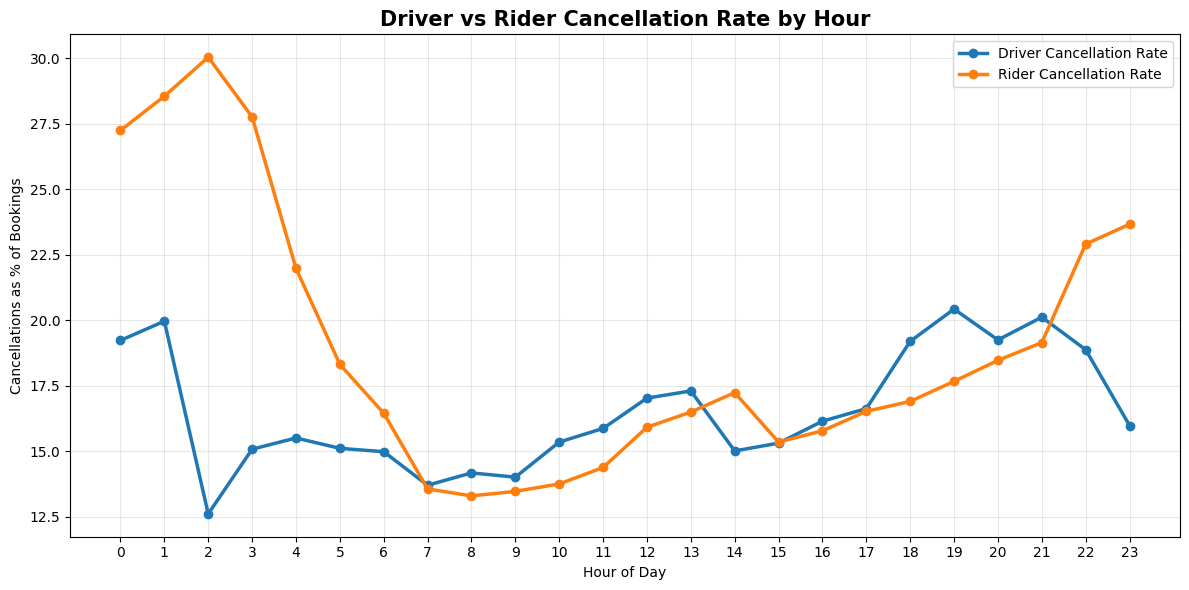

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_operations["hour"],
    hourly_operations["driver_cancel_rate"],
    marker="o",
    linewidth=2.5,
    label="Driver Cancellation Rate"
)

plt.plot(
    hourly_operations["hour"],
    hourly_operations["rider_cancel_rate"],
    marker="o",
    linewidth=2.5,
    label="Rider Cancellation Rate"
)

plt.title(
    "Driver vs Rider Cancellation Rate by Hour",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Cancellations as % of Bookings")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Driver vs Rider Cancellation Insights

Cancellation behaviour changes meaningfully throughout the day.

- During the morning period around **07:00–10:00**, driver and rider cancellation rates are relatively balanced and overall cancellation levels are comparatively low.
- As evening demand increases, both driver and rider cancellation rates rise.
- During the principal evening peak:
  - **18:00:** driver cancellations = 19.19%, rider cancellations = 16.90%
  - **19:00:** driver cancellations = 20.42%, rider cancellations = 17.66%
  - **21:00:** driver cancellations = 20.11%, rider cancellations = 19.14%
- The increase during the 18:00–21:00 period is therefore slightly more pronounced on the driver side.

### Late-Night Behaviour

The cancellation pattern changes again later in the night.

- At **22:00–23:00**, rider cancellations exceed driver cancellations.
- Rider cancellations are also particularly high during the early-morning hours between approximately **00:00 and 03:00**.

### Operational Interpretation

The observed evening deterioration appears to involve both sides of the marketplace, but driver cancellations contribute more strongly during the principal peak-demand period.

This supports the hypothesis that evening demand may place pressure on available driver capacity or driver willingness to fulfil bookings.

Late-night cancellations appear more rider-driven, suggesting that different operational interventions may be required for peak evening periods versus overnight periods.

These interpretations remain observational and do not establish the exact cause of cancellation behaviour.

**correlation between demand and service performance**

In [30]:
hourly_combined = (
    demand_q_analysis
    .merge(
        hourly_operations[
            [
                "hour",
                "completion_rate",
                "cancellation_rate",
                "driver_cancel_rate",
                "rider_cancel_rate"
            ]
        ],
        on="hour",
        how="left"
    )
)

hourly_combined.head()

,hour,observed_days,average_searches,q_success_rate,e_stage_rate,completion_rate,cancellation_rate,driver_cancel_rate,rider_cancel_rate
0,0,3,5144.67,66.00,99.60,52.622265,46.669884,19.224582,27.236165
1,1,3,4055.33,54.24,99.55,50.429185,48.783977,19.957082,28.540773
2,2,3,1363.67,79.29,99.56,56.655949,42.765273,12.604502,30.032154
3,3,3,1222.00,75.06,99.10,56.956522,42.826087,15.072464,27.753623
4,4,3,2304.00,67.47,99.64,62.285258,37.514982,15.501398,21.973632


In [31]:
relationship_metrics = hourly_combined[
    [
        "average_searches",
        "q_success_rate",
        "completion_rate",
        "cancellation_rate",
        "driver_cancel_rate",
        "rider_cancel_rate"
    ]
]

relationship_metrics.corr().round(3)

,average_searches,q_success_rate,completion_rate,cancellation_rate,driver_cancel_rate,rider_cancel_rate
average_searches,1.000,-0.682,0.170,-0.315,0.452,-0.553
q_success_rate,-0.682,1.000,0.060,-0.001,-0.758,0.318
completion_rate,0.170,0.060,1.000,-0.935,-0.528,-0.854
cancellation_rate,-0.315,-0.001,-0.935,1.000,0.530,0.931
driver_cancel_rate,0.452,-0.758,-0.528,0.530,1.000,0.197
rider_cancel_rate,-0.553,0.318,-0.854,0.931,0.197,1.000


This correlation will be based on only 24 hourly observations, so we're using it as exploratory evidence, not statistical proof of causality.

### Hourly Relationship Analysis

The correlation analysis provides additional evidence about how demand and operational performance vary across hours.

#### Key Observations

- **Average search demand and Q-stage success have a correlation of -0.682.**
  - Higher-demand hours tend to be associated with lower Q-stage success in the observed sample.
  - This supports the earlier finding that the evening demand peak coincides with weaker Q-stage performance.

- **Demand and driver cancellation rate have a moderate positive correlation of 0.452.**
  - Higher-demand periods tend to show somewhat greater driver-side cancellation pressure.

- **Demand and rider cancellation rate have a negative correlation of -0.553.**
  - Rider cancellations are comparatively more prominent during several lower-demand periods, particularly overnight.

- **Demand and overall cancellation rate show only a modest negative correlation (-0.315).**
  - Therefore, high demand should not be interpreted as automatically producing higher total cancellation rates.

- **Q-stage success and driver cancellation rate have a strong negative correlation (-0.758).**
  - Hours with weaker Q-stage success also tend to experience greater driver-side cancellation pressure.

### Interpretation

The hourly marketplace appears to experience different operational problems at different times.

During high-demand evening periods, Q-stage performance weakens and driver-side cancellations become more prominent.

During low-demand overnight periods, rider-side cancellations account for a larger share of booking failures.

These relationships are exploratory associations based on only 24 hourly observations and should not be interpreted as causal effects.

Correlations involving mathematically related metrics, such as total cancellations and rider/driver cancellation components, are interpreted cautiously because part of the relationship is structurally built into the metric definitions.

**Statistical check for time-based EDA**

**Spearman correlation** measures whether two variables tend to move in the same or opposite direction based on their ranking, rather than requiring a perfectly straight-line relationship.

In [32]:
spearman_corr = relationship_metrics.corr(method="spearman").round(3)

spearman_corr

,average_searches,q_success_rate,completion_rate,cancellation_rate,driver_cancel_rate,rider_cancel_rate
average_searches,1.000,-0.615,0.252,-0.295,0.463,-0.433
q_success_rate,-0.615,1.000,0.112,-0.140,-0.708,-0.025
completion_rate,0.252,0.112,1.000,-0.910,-0.473,-0.880
cancellation_rate,-0.295,-0.140,-0.910,1.000,0.540,0.962
driver_cancel_rate,0.463,-0.708,-0.473,0.540,1.000,0.364
rider_cancel_rate,-0.433,-0.025,-0.880,0.962,0.364,1.000


### Spearman Correlation Check

A Spearman rank-correlation analysis was performed as an additional robustness check because hourly marketplace behaviour is not perfectly linear.

The results support the main Pearson-correlation findings:

- Search demand vs Q-stage success: **-0.615**
- Search demand vs driver cancellation rate: **+0.463**
- Search demand vs rider cancellation rate: **-0.433**
- Q-stage success vs driver cancellation rate: **-0.708**

The direction and approximate strength of these relationships remain similar under both Pearson and Spearman correlation.

This strengthens the exploratory evidence that high-demand periods are associated with weaker Q-stage performance and increased driver-side cancellation pressure.

However, the analysis is based on only 24 hourly observations and should therefore be treated as exploratory rather than causal.

---

## 6. Vehicle Type & Trip Category Analysis

The next stage examines how operational performance differs across vehicle types and trip categories.

The analysis will compare:

- Booking volume
- Completed rides
- Cancellation volume and rate
- Driver vs rider cancellations
- Earnings
- Earnings per completed ride

Before aggregation, the available categorical values are inspected to ensure that summary categories are not accidentally double counted.

In [33]:
print("Vehicle Types:")
print(city_operations["vehicle_type"].value_counts(dropna=False))

print("\nTrip Categories:")
print(city_operations["trip_category"].value_counts(dropna=False))

print("\nBooking Types:")
print(city_operations["booking_type"].value_counts(dropna=False))

Vehicle Types:
vehicle_type
Cab     306
Auto    199
Name: count, dtype: int64

Trip Categories:
trip_category
OneWay       255
Rental       147
InterCity    103
Name: count, dtype: int64

Booking Types:
booking_type
Normal    319
Purple    186
Name: count, dtype: int64


In [34]:
category_combinations = (
    city_operations[
        ["vehicle_type", "trip_category", "booking_type"]
    ]
    .drop_duplicates()
    .sort_values(
        ["vehicle_type", "trip_category", "booking_type"]
    )
    .reset_index(drop=True)
)

category_combinations

,vehicle_type,trip_category,booking_type
0,Auto,OneWay,Normal
1,Auto,OneWay,Purple
2,Auto,Rental,Normal
3,Auto,Rental,Purple
4,Cab,InterCity,Normal
5,Cab,InterCity,Purple
6,Cab,OneWay,Normal
7,Cab,OneWay,Purple
8,Cab,Rental,Normal
9,Cab,Rental,Purple


### Operational Category Structure

The processed operational dataset contains two vehicle categories:

- `Auto`
- `Cab`

Three trip categories are available:

- `OneWay`
- `Rental`
- `InterCity`

`InterCity` activity is available only for Cab, while both Auto and Cab contain OneWay and Rental activity.

Two booking-type labels are present:

- `Normal`
- `Purple`

The meaning of `Purple` is retained as a source-system category and is not interpreted further without an official definition.

Importantly, the operational dataset contains no `"All"` vehicle summary rows. Therefore, Auto and Cab operational activity can be aggregated directly without introducing the double counting identified and prevented during Phase 1.

**Vehicle type performance**

In [35]:
vehicle_summary = (
    city_operations
    .groupby("vehicle_type", as_index=False)
    .agg(
        bookings=("booking", "sum"),
        rides=("rides", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        driver_cancels=("drvr_cancel", "sum"),
        rider_cancels=("rider_cancel", "sum"),
        earnings=("earning", "sum")
    )
)

vehicle_summary["completion_rate"] = (
    vehicle_summary["completed_rides"]
    / vehicle_summary["bookings"] * 100
)

vehicle_summary["cancellation_rate"] = (
    vehicle_summary["cancelled_rides"]
    / vehicle_summary["bookings"] * 100
)

vehicle_summary["earnings_per_completed_ride"] = (
    vehicle_summary["earnings"]
    / vehicle_summary["completed_rides"]
)

vehicle_summary.round(2)

,vehicle_type,bookings,rides,completed_rides,cancelled_rides,driver_cancels,rider_cancels,earnings,completion_rate,cancellation_rate,earnings_per_completed_ride
0,Auto,356278,356204,236980,110233,57839,52172,34826177,66.52,30.94,146.96
1,Cab,86308,83907,45562,38408,16431,21575,18668076,52.79,44.50,409.73


In [36]:
#Verifying that nothing was lost

print("Vehicle summary bookings :", vehicle_summary["bookings"].sum())
print("Baseline bookings        :", total_bookings)

print("\nVehicle summary completed:", vehicle_summary["completed_rides"].sum())
print("Baseline completed       :", completed_rides)

print("\nVehicle summary cancels  :", vehicle_summary["cancelled_rides"].sum())
print("Baseline cancels         :", cancelled_rides)

print("\nVehicle summary earnings :", vehicle_summary["earnings"].sum())
print("Baseline earnings        :", total_earnings)

Vehicle summary bookings : 442586
Baseline bookings        : 442586

Vehicle summary completed: 282542
Baseline completed       : 282542

Vehicle summary cancels  : 148641
Baseline cancels         : 148641

Vehicle summary earnings : 53494253
Baseline earnings        : 53494253


**Vehicle comparison chart**

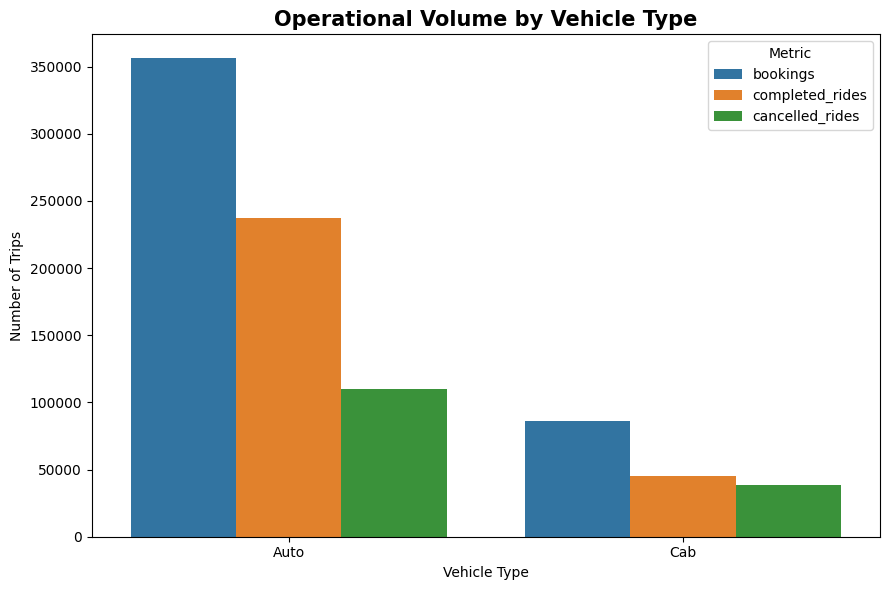

In [37]:
plt.figure(figsize=(9, 6))

vehicle_plot = vehicle_summary.melt(
    id_vars="vehicle_type",
    value_vars=["bookings", "completed_rides", "cancelled_rides"],
    var_name="Metric",
    value_name="Count"
)

sns.barplot(
    data=vehicle_plot,
    x="vehicle_type",
    y="Count",
    hue="Metric"
)

plt.title(
    "Operational Volume by Vehicle Type",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Number of Trips")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Vehicle-Type Performance Insights

Vehicle-level analysis shows substantial differences between Auto and Cab operations.

- **Auto dominates operational volume**, contributing the majority of bookings and completed rides.
- Auto records **356,278 bookings**, compared with **86,308 Cab bookings**.
- Auto also demonstrates stronger fulfilment:
  - Auto completion rate: **66.52%**
  - Cab completion rate: **52.79%**
- Cab experiences considerably greater cancellation pressure:
  - Auto cancellation rate: **30.94%**
  - Cab cancellation rate: **44.50%**
- Auto generates greater total earnings because of its much larger ride volume.
- However, earnings per completed ride are substantially higher for Cab:
  - Auto: approximately **₹146.96**
  - Cab: approximately **₹409.73**

### Interpretation

Auto appears to be the dominant high-volume mobility product in the observed data, with stronger completion and lower cancellation rates.

Cab generates significantly higher earnings per completed ride, but this should not be interpreted as a pure vehicle-type effect because Cab also contains InterCity activity and may have a different trip-distance and trip-category mix.

The next analysis therefore separates performance by trip category before drawing stronger conclusions about vehicle-level economics.

**Trip category analysis**

In [38]:
trip_summary = (
    city_operations
    .groupby("trip_category", as_index=False)
    .agg(
        bookings=("booking", "sum"),
        rides=("rides", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        driver_cancels=("drvr_cancel", "sum"),
        rider_cancels=("rider_cancel", "sum"),
        earnings=("earning", "sum")
    )
)

trip_summary["completion_rate"] = (
    trip_summary["completed_rides"]
    / trip_summary["bookings"] * 100
)

trip_summary["cancellation_rate"] = (
    trip_summary["cancelled_rides"]
    / trip_summary["bookings"] * 100
)

trip_summary["earnings_per_completed_ride"] = (
    trip_summary["earnings"]
    / trip_summary["completed_rides"]
)

trip_summary.round(2)

,trip_category,bookings,rides,completed_rides,cancelled_rides,driver_cancels,rider_cancels,earnings,completion_rate,cancellation_rate,earnings_per_completed_ride
0,InterCity,1033,854,169,839,291,458,305789,16.36,81.22,1809.40
1,OneWay,440554,438424,282132,147096,73620,73040,52952562,64.04,33.39,187.69
2,Rental,999,833,241,706,359,249,235902,24.12,70.67,978.85


In [39]:
#Verifying total gains

print("Trip summary bookings :", trip_summary["bookings"].sum())
print("Baseline bookings     :", total_bookings)

print("\nTrip summary completed:", trip_summary["completed_rides"].sum())
print("Baseline completed    :", completed_rides)

print("\nTrip summary cancels  :", trip_summary["cancelled_rides"].sum())
print("Baseline cancels      :", cancelled_rides)

print("\nTrip summary earnings :", trip_summary["earnings"].sum())
print("Baseline earnings     :", total_earnings)

Trip summary bookings : 442586
Baseline bookings     : 442586

Trip summary completed: 282542
Baseline completed    : 282542

Trip summary cancels  : 148641
Baseline cancels      : 148641

Trip summary earnings : 53494253
Baseline earnings     : 53494253


**Vehicle x Trip summary**

In [40]:
vehicle_trip_summary = (
    city_operations
    .groupby(["vehicle_type", "trip_category"], as_index=False)
    .agg(
        bookings=("booking", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        earnings=("earning", "sum")
    )
)

vehicle_trip_summary["completion_rate"] = (
    vehicle_trip_summary["completed_rides"]
    / vehicle_trip_summary["bookings"] * 100
)

vehicle_trip_summary["cancellation_rate"] = (
    vehicle_trip_summary["cancelled_rides"]
    / vehicle_trip_summary["bookings"] * 100
)

vehicle_trip_summary["earnings_per_completed_ride"] = (
    vehicle_trip_summary["earnings"]
    / vehicle_trip_summary["completed_rides"]
)

vehicle_trip_summary.round(2)

,vehicle_type,trip_category,bookings,completed_rides,cancelled_rides,earnings,completion_rate,cancellation_rate,earnings_per_completed_ride
0,Auto,OneWay,356043,236907,110086,34796358,66.54,30.92,146.88
1,Auto,Rental,235,73,147,29819,31.06,62.55,408.48
2,Cab,InterCity,1033,169,839,305789,16.36,81.22,1809.40
3,Cab,OneWay,84511,45225,37010,18156204,53.51,43.79,401.46
4,Cab,Rental,764,168,559,206083,21.99,73.17,1226.68


### Trip-Category and Vehicle–Trip Insights

Trip-category analysis shows that operational activity is overwhelmingly concentrated in `OneWay` trips.

- `OneWay` contributes approximately **99.54% of all bookings** in the observed operational dataset.
- Rental and InterCity bookings represent only a very small share of total volume.

### OneWay Performance

OneWay is the core operational category:

- Completion rate: **64.04%**
- Cancellation rate: **33.39%**
- Earnings per completed ride: approximately **₹187.69**

### Rental and InterCity Performance

Rental and InterCity trips show substantially higher cancellation rates:

- Rental cancellation rate: **70.67%**
- InterCity cancellation rate: **81.22%**

However, both categories have very small booking volumes, so their rates should be interpreted cautiously.

These categories also generate much higher earnings per completed ride, consistent with their different trip characteristics and likely longer-distance or longer-duration usage.

### Vehicle × Trip Category

Separating vehicle type from trip category provides a clearer comparison.

For OneWay trips:

- Auto completion rate: **66.54%**
- Cab completion rate: **53.51%**
- Auto cancellation rate: **30.92%**
- Cab cancellation rate: **43.79%**

Cab OneWay trips therefore experience weaker fulfilment than Auto OneWay trips even after controlling for trip category at this descriptive level.

Cab also generates substantially higher earnings per completed OneWay ride.

### Interpretation

The earlier difference between Auto and Cab is not explained solely by InterCity and Rental activity.

Even within the dominant OneWay category, Cab shows higher earnings per completed ride but also lower completion and higher cancellation rates.

Rental and InterCity appear economically higher-value per successful trip, but their very small observed sample sizes and high cancellation rates require cautious interpretation.

**Trip category visualization**

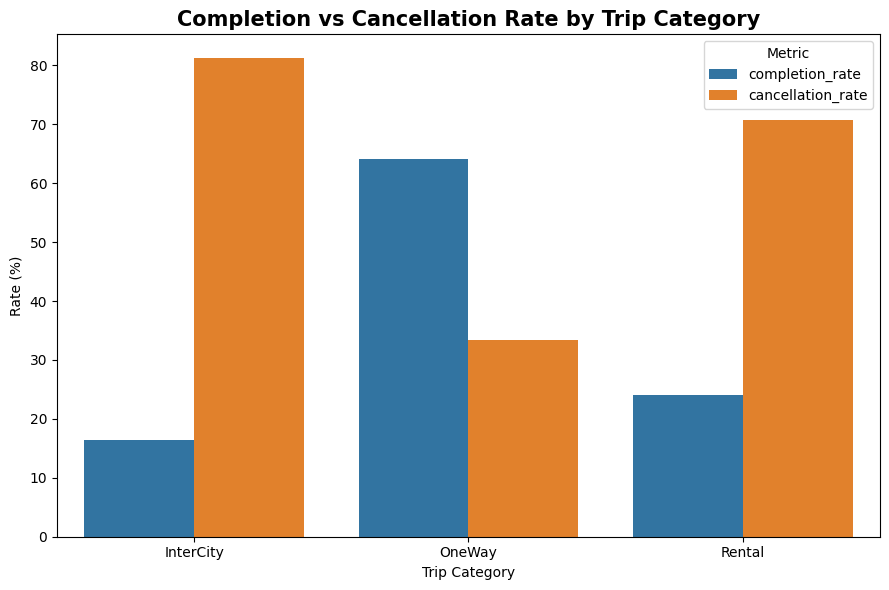

In [41]:
plt.figure(figsize=(9, 6))

trip_rate_plot = trip_summary.melt(
    id_vars="trip_category",
    value_vars=["completion_rate", "cancellation_rate"],
    var_name="Metric",
    value_name="Rate"
)

sns.barplot(
    data=trip_rate_plot,
    x="trip_category",
    y="Rate",
    hue="Metric"
)

plt.title(
    "Completion vs Cancellation Rate by Trip Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Trip Category")
plt.ylabel("Rate (%)")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Booking-Type Analysis

The operational dataset contains two booking-type labels:

- `Normal`
- `Purple`

Because the source data does not provide a confirmed business definition for `Purple`, the label is retained as-is.

The analysis compares the two booking types descriptively using:

- Booking volume
- Completed rides
- Cancellation rate
- Driver and rider cancellations
- Earnings
- Earnings per completed ride

**Booking type summary**

In [42]:
booking_type_summary = (
    city_operations
    .groupby("booking_type", as_index=False)
    .agg(
        bookings=("booking", "sum"),
        rides=("rides", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        driver_cancels=("drvr_cancel", "sum"),
        rider_cancels=("rider_cancel", "sum"),
        earnings=("earning", "sum")
    )
)

booking_type_summary["completion_rate"] = (
    booking_type_summary["completed_rides"]
    / booking_type_summary["bookings"] * 100
)

booking_type_summary["cancellation_rate"] = (
    booking_type_summary["cancelled_rides"]
    / booking_type_summary["bookings"] * 100
)

booking_type_summary["earnings_per_completed_ride"] = (
    booking_type_summary["earnings"]
    / booking_type_summary["completed_rides"]
)

booking_type_summary.round(2)

,booking_type,bookings,rides,completed_rides,cancelled_rides,driver_cancels,rider_cancels,earnings,completion_rate,cancellation_rate,earnings_per_completed_ride
0,Normal,439548,437111,280882,147335,73590,73127,53187423,63.90,33.52,189.36
1,Purple,3038,3000,1660,1306,680,620,306830,54.64,42.99,184.84


In [43]:
print("Booking-type bookings :", booking_type_summary["bookings"].sum())
print("Baseline bookings     :", total_bookings)

print("\nBooking-type completed:", booking_type_summary["completed_rides"].sum())
print("Baseline completed    :", completed_rides)

print("\nBooking-type cancels  :", booking_type_summary["cancelled_rides"].sum())
print("Baseline cancels      :", cancelled_rides)

print("\nBooking-type earnings :", booking_type_summary["earnings"].sum())
print("Baseline earnings     :", total_earnings)

Booking-type bookings : 442586
Baseline bookings     : 442586

Booking-type completed: 282542
Baseline completed    : 282542

Booking-type cancels  : 148641
Baseline cancels      : 148641

Booking-type earnings : 53494253
Baseline earnings     : 53494253


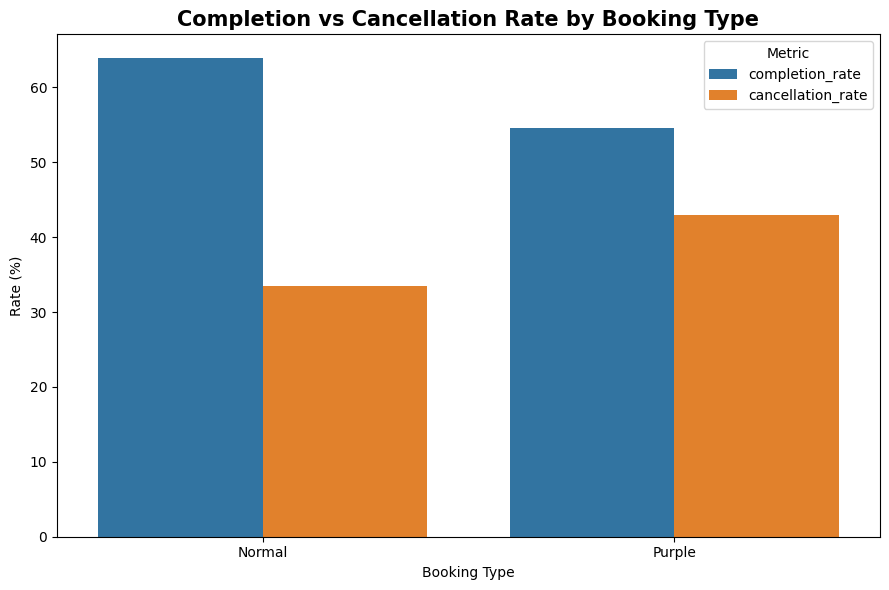

In [44]:
plt.figure(figsize=(9, 6))

booking_type_plot = booking_type_summary.melt(
    id_vars="booking_type",
    value_vars=["completion_rate", "cancellation_rate"],
    var_name="Metric",
    value_name="Rate"
)

sns.barplot(
    data=booking_type_plot,
    x="booking_type",
    y="Rate",
    hue="Metric"
)

plt.title(
    "Completion vs Cancellation Rate by Booking Type",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Booking Type")
plt.ylabel("Rate (%)")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Booking-Type Insights

Booking activity is overwhelmingly concentrated in the `Normal` booking type.

- `Normal` accounts for approximately **99.3% of all bookings**.
- `Purple` contributes only about **0.7% of total booking volume**.

Operationally:

- Normal completion rate: **63.90%**
- Purple completion rate: **54.64%**
- Normal cancellation rate: **33.52%**
- Purple cancellation rate: **42.99%**

Purple therefore shows weaker fulfilment within the observed sample.

However, because Purple represents a very small share of total activity and its exact business definition is not confirmed, the difference should be interpreted cautiously.

Earnings per completed ride are very similar between the two booking types, suggesting that the primary observed difference is related to fulfilment rather than earnings per successful ride.

**Final composition check**

In [45]:
booking_mix = (
    city_operations
    .groupby(
        ["booking_type", "vehicle_type", "trip_category"],
        as_index=False
    )
    .agg(
        bookings=("booking", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum")
    )
)

booking_mix["completion_rate"] = (
    booking_mix["completed_rides"]
    / booking_mix["bookings"] * 100
)

booking_mix["cancellation_rate"] = (
    booking_mix["cancelled_rides"]
    / booking_mix["bookings"] * 100
)

booking_mix.round(2)

,booking_type,vehicle_type,trip_category,bookings,completed_rides,cancelled_rides,completion_rate,cancellation_rate
0,Normal,Auto,OneWay,353624,235481,109152,66.59,30.87
1,Normal,Auto,Rental,235,73,147,31.06,62.55
2,Normal,Cab,InterCity,994,168,801,16.90,80.58
3,Normal,Cab,OneWay,83937,44993,36681,53.60,43.70
4,Normal,Cab,Rental,758,167,554,22.03,73.09
5,Purple,Auto,OneWay,2419,1426,934,58.95,38.61
6,Purple,Auto,Rental,0,0,0,NaN,NaN
7,Purple,Cab,InterCity,39,1,38,2.56,97.44
8,Purple,Cab,OneWay,574,232,329,40.42,57.32
9,Purple,Cab,Rental,6,1,5,16.67,83.33


In [46]:
booking_mix_share = (
    booking_mix
    .copy()
)

booking_mix_share["booking_type_total"] = (
    booking_mix_share
    .groupby("booking_type")["bookings"]
    .transform("sum")
)

booking_mix_share["within_type_share_%"] = (
    booking_mix_share["bookings"]
    / booking_mix_share["booking_type_total"] * 100
)

booking_mix_share[
    [
        "booking_type",
        "vehicle_type",
        "trip_category",
        "bookings",
        "within_type_share_%",
        "completion_rate",
        "cancellation_rate"
    ]
].round(2)

,booking_type,vehicle_type,trip_category,bookings,within_type_share_%,completion_rate,cancellation_rate
0,Normal,Auto,OneWay,353624,80.45,66.59,30.87
1,Normal,Auto,Rental,235,0.05,31.06,62.55
2,Normal,Cab,InterCity,994,0.23,16.90,80.58
3,Normal,Cab,OneWay,83937,19.10,53.60,43.70
4,Normal,Cab,Rental,758,0.17,22.03,73.09
5,Purple,Auto,OneWay,2419,79.62,58.95,38.61
6,Purple,Auto,Rental,0,0.00,NaN,NaN
7,Purple,Cab,InterCity,39,1.28,2.56,97.44
8,Purple,Cab,OneWay,574,18.89,40.42,57.32
9,Purple,Cab,Rental,6,0.20,16.67,83.33


### Booking-Type Composition Check

The weaker performance observed for the `Purple` booking type is not explained solely by differences in vehicle or trip-category composition.

Both booking types have a very similar operational mix:

- Approximately 80% of activity comes from Auto OneWay trips.
- Approximately 19% comes from Cab OneWay trips.
- Rental and InterCity activity represent only a very small share.

Performance differences remain visible even within the same dominant segments.

For Auto OneWay trips:

- Normal completion rate: 66.59%
- Purple completion rate: 58.95%
- Normal cancellation rate: 30.87%
- Purple cancellation rate: 38.61%

For Cab OneWay trips:

- Normal completion rate: 53.60%
- Purple completion rate: 40.42%
- Normal cancellation rate: 43.70%
- Purple cancellation rate: 57.32%

This indicates that the observed Purple-vs-Normal fulfilment gap is not purely a result of different vehicle/trip mixes.

However, because the exact business meaning of `Purple` is not confirmed and Purple represents a very small portion of total bookings, no causal interpretation is made.

---

## 7. Ward-Level Funnel & Geographic Demand Analysis

City-level analysis identifies when operational pressure occurs, but it does not reveal where that pressure is concentrated.

The ward-level funnel dataset is therefore used to identify geographic differences in:

- Search demand
- Q-stage progression
- Bookings
- Completed rides
- Cancellations
- Conversion behaviour
- Vehicle and trip-category activity

This analysis will later be combined with driver-supply information to identify potential demand–supply mismatch zones across Bengaluru.

In [47]:
# ============================================================
# 7.1 Inspect Ward-Level Funnel Dataset
# ============================================================

print("Ward funnel shape:", ward_funnel.shape)
print("Number of unique wards:", ward_funnel['ward_num'].nunique())

print("\nColumns:")
for col in ward_funnel.columns:
    print(col)

Ward funnel shape: (2928, 29)
Number of unique wards: 244

Columns:
ward_num
srch_fr_e
srch_which_got_e
srch_fr_q
srch_which_got_q
booking
ongng_ride
done_ride
rides
cancel_ride
drvr_cancel
rider_cancel
earning
dist
avg_dist_pr_trip
avg_fare
trip_category
vehicle_type
srch_fr_q_variant
srch_which_got_q_variant
is_bike
is_cab
is_auto
srch_to_e_rate
e_to_q_srch_rate
q_accept_rate
q_to_bkng_rate
cnvr_rate
bkng_cancel_rate


One important rule for the ward analysis: we should not average columns such as q_accept_rate, cnvr_rate, or bkng_cancel_rate across rows. We’ll aggregate the underlying counts first and then recalculate the rates at ward level.

**Ward-level demand aggregation**

In [48]:
# ============================================================
# 7.2 Ward-Level Demand Aggregation
# ============================================================

# Raw metrics that can be safely summed across
# vehicle types and trip categories within each ward
ward_sum_cols = [
    'srch_fr_e',
    'srch_which_got_e',
    'srch_fr_q',
    'srch_which_got_q',
    'booking',
    'ongng_ride',
    'done_ride',
    'rides',
    'cancel_ride',
    'drvr_cancel',
    'rider_cancel',
    'earning',
    'dist'
]

ward_summary = (
    ward_funnel
    .groupby('ward_num', as_index=False)[ward_sum_cols]
    .sum()
)

print("Ward summary shape:", ward_summary.shape)
print("Unique wards:", ward_summary['ward_num'].nunique())

display(ward_summary.head(10))

Ward summary shape: (244, 14)
Unique wards: 244


,ward_num,srch_fr_e,srch_which_got_e,srch_fr_q,srch_which_got_q,booking,ongng_ride,done_ride,rides,cancel_ride,drvr_cancel,rider_cancel,earning,dist
0,b_1,72,72,39,21,19,1,12,19,6,3,3,2507,106.271
1,b_10,188,188,139,65,65,5,32,65,27,15,12,8413,333.565
2,b_100,159,159,129,56,56,5,37,56,13,3,10,6783,257.045
3,b_101,43,43,29,19,19,3,5,19,9,4,5,1118,46.269
4,b_102,127,127,110,52,50,3,23,50,24,10,14,5165,197.180
5,b_103,172,172,140,70,70,1,37,70,31,14,16,8027,303.165
6,b_104,70,70,51,21,21,2,7,21,11,4,7,2016,80.086
7,b_105,436,436,336,120,117,1,62,117,53,30,23,21893,901.160
8,b_106,216,216,155,79,77,3,43,77,30,11,19,11938,460.700
9,b_107,70,70,42,25,24,1,11,24,12,5,6,2195,77.292


**Q. what we are checking ?**

-> Every value in the **difference** column should be 0 or 0.0 because that confirms Aggregating the 2,928 vehicle/trip-category records into 244 wards did not lose or duplicate any activity.

In [49]:
# ============================================================
# 7.2.1 Validate Ward Aggregation
# ============================================================

validation = []

for col in ward_sum_cols:
    original_total = ward_funnel[col].sum()
    aggregated_total = ward_summary[col].sum()

    validation.append({
        'metric': col,
        'original_total': original_total,
        'ward_summary_total': aggregated_total,
        'difference': aggregated_total - original_total
    })

validation_df = pd.DataFrame(validation)

display(validation_df)

,metric,original_total,ward_summary_total,difference
0,srch_fr_e,36112.000,36112.000,0.0
1,srch_which_got_e,36090.000,36090.000,0.0
2,srch_fr_q,27618.000,27618.000,0.0
3,srch_which_got_q,11609.000,11609.000,0.0
4,booking,9936.000,9936.000,0.0
5,ongng_ride,583.000,583.000,0.0
6,done_ride,4778.000,4778.000,0.0
7,rides,9706.000,9706.000,0.0
8,cancel_ride,4347.000,4347.000,0.0
9,drvr_cancel,1954.000,1954.000,0.0


ward_summary is:

- 244 wards × 14 columns

- Every aggregated total exactly matches the original ward_funnel

- All 13 differences = 0.0

So we can safely continue with the actual ward-level analysis.

One useful observation already: the ward dataset contains 36,112 search requests, 9,936 bookings, and 4,347 cancelled rides across the available ward-level data. We’ll interpret those properly after calculating the ward KPIs.

**Recalculate ward level funnel KPI**

In [50]:
# ============================================================
# 7.3 Ward-Level Funnel KPIs
# ============================================================

# Search -> E-stage
ward_summary['srch_to_e_rate'] = (
    ward_summary['srch_which_got_e']
    .div(ward_summary['srch_fr_e'])
    .mul(100)
    .where(ward_summary['srch_fr_e'] > 0)
)

# E-stage -> Q search/request
ward_summary['e_to_q_srch_rate'] = (
    ward_summary['srch_fr_q']
    .div(ward_summary['srch_which_got_e'])
    .mul(100)
    .where(ward_summary['srch_which_got_e'] > 0)
)

# Q request -> Quote received
ward_summary['q_accept_rate'] = (
    ward_summary['srch_which_got_q']
    .div(ward_summary['srch_fr_q'])
    .mul(100)
    .where(ward_summary['srch_fr_q'] > 0)
)

# Quote received -> Booking
ward_summary['q_to_bkng_rate'] = (
    ward_summary['booking']
    .div(ward_summary['srch_which_got_q'])
    .mul(100)
    .where(ward_summary['srch_which_got_q'] > 0)
)

# Overall Search -> Booking conversion
ward_summary['cnvr_rate'] = (
    ward_summary['booking']
    .div(ward_summary['srch_fr_e'])
    .mul(100)
    .where(ward_summary['srch_fr_e'] > 0)
)

# Booking cancellation rate
ward_summary['bkng_cancel_rate'] = (
    ward_summary['cancel_ride']
    .div(ward_summary['booking'])
    .mul(100)
    .where(ward_summary['booking'] > 0)
)

# Completed ride rate relative to bookings
ward_summary['completion_rate'] = (
    ward_summary['done_ride']
    .div(ward_summary['booking'])
    .mul(100)
    .where(ward_summary['booking'] > 0)
)

kpi_cols = [
    'ward_num',
    'srch_fr_e',
    'booking',
    'done_ride',
    'srch_to_e_rate',
    'e_to_q_srch_rate',
    'q_accept_rate',
    'q_to_bkng_rate',
    'cnvr_rate',
    'bkng_cancel_rate',
    'completion_rate'
]

display(
    ward_summary[kpi_cols]
    .round(2)
    .head(10)
)

,ward_num,srch_fr_e,booking,done_ride,srch_to_e_rate,e_to_q_srch_rate,q_accept_rate,q_to_bkng_rate,cnvr_rate,bkng_cancel_rate,completion_rate
0,b_1,72,19,12,100.0,54.17,53.85,90.48,26.39,31.58,63.16
1,b_10,188,65,32,100.0,73.94,46.76,100.00,34.57,41.54,49.23
2,b_100,159,56,37,100.0,81.13,43.41,100.00,35.22,23.21,66.07
3,b_101,43,19,5,100.0,67.44,65.52,100.00,44.19,47.37,26.32
4,b_102,127,50,23,100.0,86.61,47.27,96.15,39.37,48.00,46.00
5,b_103,172,70,37,100.0,81.40,50.00,100.00,40.70,44.29,52.86
6,b_104,70,21,7,100.0,72.86,41.18,100.00,30.00,52.38,33.33
7,b_105,436,117,62,100.0,77.06,35.71,97.50,26.83,45.30,52.99
8,b_106,216,77,43,100.0,71.76,50.97,97.47,35.65,38.96,55.84
9,b_107,70,24,11,100.0,60.00,59.52,96.00,34.29,50.00,45.83


**Find the top 10 highest demand wards**

In [51]:
# ============================================================
# 7.4 Top 10 Wards by Search Demand
# ============================================================

top_demand_wards = (
    ward_summary
    .sort_values('srch_fr_e', ascending=False)
    .head(10)
    [
        [
            'ward_num',
            'srch_fr_e',
            'srch_fr_q',
            'srch_which_got_q',
            'booking',
            'done_ride',
            'cnvr_rate',
            'bkng_cancel_rate'
        ]
    ]
)

display(top_demand_wards.round(2))

,ward_num,srch_fr_e,srch_fr_q,srch_which_got_q,booking,done_ride,cnvr_rate,bkng_cancel_rate
91,b_181,4862,4522,560,556,216,11.44,60.43
243,w_0,3460,2646,2217,776,370,22.43,40.46
97,b_187,1874,1637,445,440,141,23.48,65.68
38,b_133,1319,925,397,389,156,29.49,48.07
87,b_178,1119,1023,295,279,129,24.93,52.33
39,b_134,1021,730,282,275,99,26.93,44.36
96,b_186,1008,867,267,266,122,26.39,52.63
25,b_121,823,721,224,224,108,27.22,48.66
234,b_91,643,512,182,150,72,23.33,38.67
36,b_131,516,470,73,69,29,13.37,57.97


Ward-Level visualization

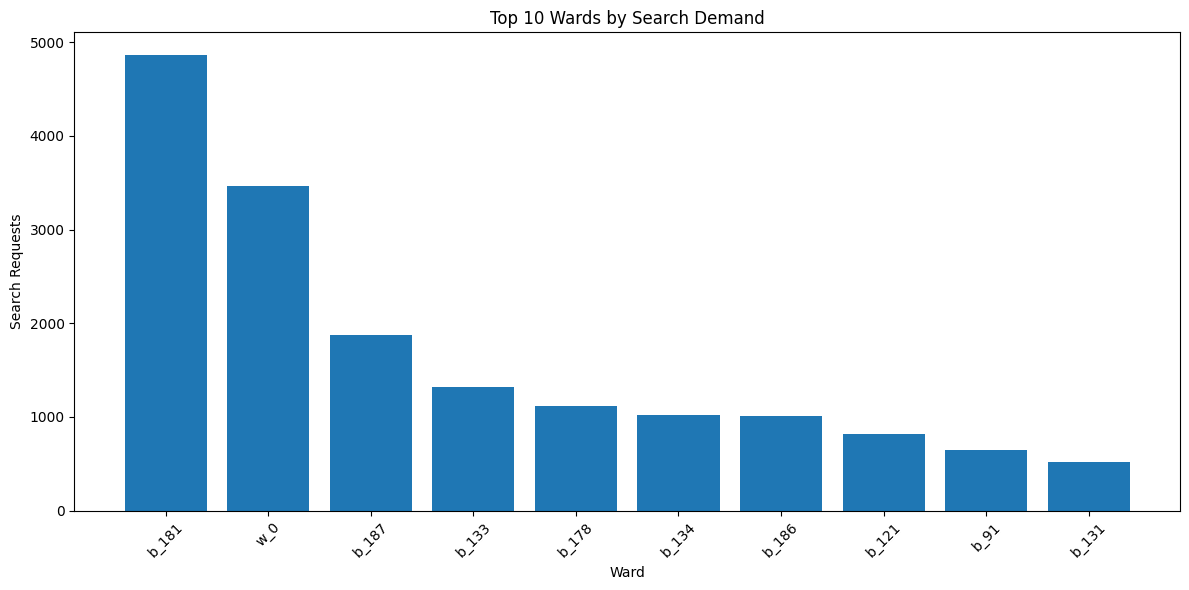

In [52]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_demand_wards['ward_num'],
    top_demand_wards['srch_fr_e']
)

plt.title('Top 10 Wards by Search Demand')
plt.xlabel('Ward')
plt.ylabel('Search Requests')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Initial Ward-Level Demand Findings

Search demand is highly concentrated in a small number of wards rather than being evenly distributed across Bengaluru.

- **b_181** records the highest demand with 4,862 search requests, substantially exceeding all other wards. However, its overall search-to-booking conversion rate is only **11.44%**, while its booking cancellation rate reaches **60.43%**.
- **w_0** is the second-highest demand zone with 3,460 searches and shows comparatively stronger conversion at **22.43%**.
- **b_187** combines high demand with a very high cancellation rate of **65.68%**, indicating possible operational pressure after booking.
- **b_131** also shows weak conversion (**13.37%**) and a high cancellation rate (**57.97%**).

These patterns suggest that high demand does not necessarily translate into successful rides. The next analysis therefore identifies wards where high search demand is combined with relatively weak conversion performance.

**Highest-Demand + Low-Conversion hotspots**

High demand: search demand ≥ 75th percentile

Low conversion: conversion < median conversion across wards

In [53]:
# ============================================================
# 7.5 High-Demand + Low-Conversion Hotspots
# ============================================================

demand_threshold = ward_summary['srch_fr_e'].quantile(0.75)
conversion_threshold = ward_summary['cnvr_rate'].median()

print(f"75th percentile demand threshold: {demand_threshold:.2f}")
print(f"Median conversion rate: {conversion_threshold:.2f}%")

hotspot_wards = (
    ward_summary[
        (ward_summary['srch_fr_e'] >= demand_threshold) &
        (ward_summary['cnvr_rate'] < conversion_threshold)
    ]
    .sort_values('srch_fr_e', ascending=False)
)

print("\nNumber of high-demand, low-conversion wards:", len(hotspot_wards))

display(
    hotspot_wards[
        [
            'ward_num',
            'srch_fr_e',
            'srch_fr_q',
            'srch_which_got_q',
            'booking',
            'done_ride',
            'q_accept_rate',
            'cnvr_rate',
            'bkng_cancel_rate',
            'completion_rate'
        ]
    ].round(2)
)

75th percentile demand threshold: 117.75
Median conversion rate: 33.33%

Number of high-demand, low-conversion wards: 35


,ward_num,srch_fr_e,srch_fr_q,srch_which_got_q,booking,done_ride,q_accept_rate,cnvr_rate,bkng_cancel_rate,completion_rate
91,b_181,4862,4522,560,556,216,12.38,11.44,60.43,38.85
243,w_0,3460,2646,2217,776,370,83.79,22.43,40.46,47.68
97,b_187,1874,1637,445,440,141,27.18,23.48,65.68,32.05
38,b_133,1319,925,397,389,156,42.92,29.49,48.07,40.10
87,b_178,1119,1023,295,279,129,28.84,24.93,52.33,46.24
39,b_134,1021,730,282,275,99,38.63,26.93,44.36,36.00
96,b_186,1008,867,267,266,122,30.80,26.39,52.63,45.86
25,b_121,823,721,224,224,108,31.07,27.22,48.66,48.21
234,b_91,643,512,182,150,72,35.55,23.33,38.67,48.00
36,b_131,516,470,73,69,29,15.53,13.37,57.97,42.03


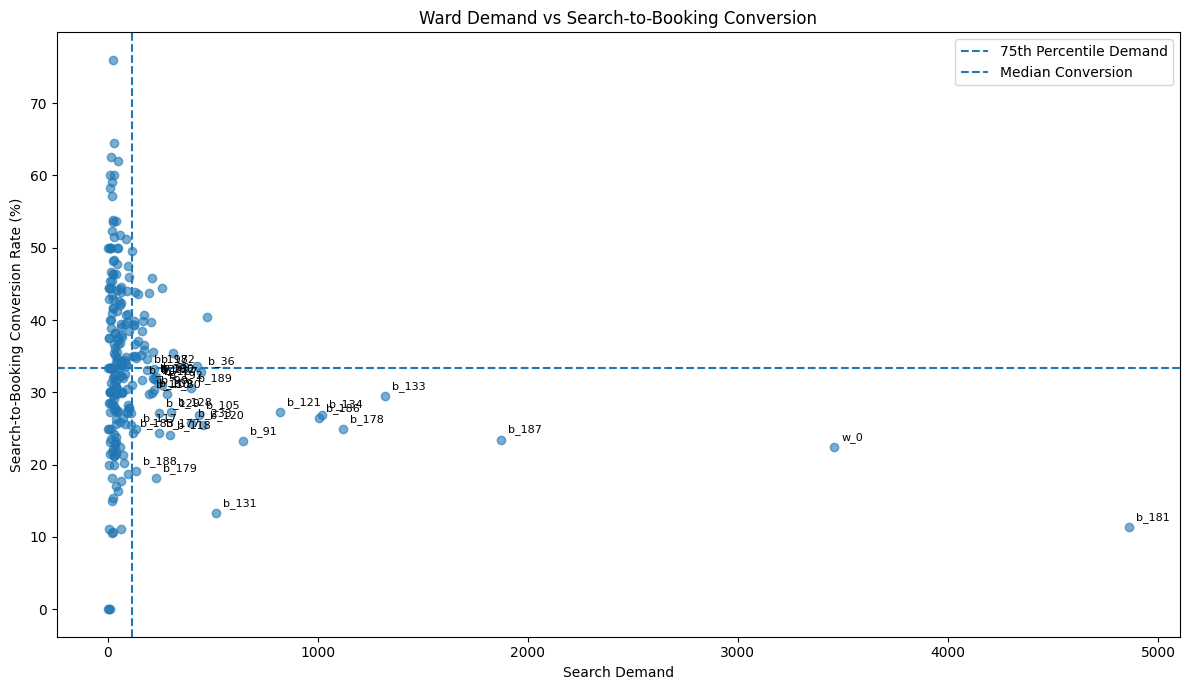

In [54]:
plt.figure(figsize=(12, 7))

plt.scatter(
    ward_summary['srch_fr_e'],
    ward_summary['cnvr_rate'],
    alpha=0.6
)

# Threshold lines
plt.axvline(
    demand_threshold,
    linestyle='--',
    label='75th Percentile Demand'
)

plt.axhline(
    conversion_threshold,
    linestyle='--',
    label='Median Conversion'
)

# Label hotspot wards
for _, row in hotspot_wards.iterrows():
    plt.annotate(
        row['ward_num'],
        (row['srch_fr_e'], row['cnvr_rate']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.title('Ward Demand vs Search-to-Booking Conversion')
plt.xlabel('Search Demand')
plt.ylabel('Search-to-Booking Conversion Rate (%)')
plt.legend()

plt.tight_layout()
plt.show()

### 7.6 Booking Opportunity Gap in High-Demand Hotspots

The previous analysis identified wards with unusually high search demand but below-median search-to-booking conversion.

To quantify the potential opportunity, we estimate the number of bookings each hotspot could generate if its conversion rate improved to the median ward conversion rate.

This is a benchmark-based opportunity estimate rather than a causal prediction. It helps prioritize wards where improving driver availability, quotation success, or booking completion may have the greatest operational impact.

**Q. If these high-demand wards performed at least as well as the median ward, how many additional bookings could theoretically be captured?**

In [55]:
# ============================================================
# 7.6 Booking Opportunity Gap
# ============================================================

hotspot_opportunity = hotspot_wards.copy()

# Expected bookings if each hotspot reached the median
# ward conversion rate
hotspot_opportunity['expected_bookings_at_median'] = (
    hotspot_opportunity['srch_fr_e'] *
    (conversion_threshold / 100)
)

# Estimated incremental booking opportunity
hotspot_opportunity['booking_opportunity_gap'] = (
    hotspot_opportunity['expected_bookings_at_median']
    - hotspot_opportunity['booking']
)

# Do not allow negative opportunity values
hotspot_opportunity['booking_opportunity_gap'] = (
    hotspot_opportunity['booking_opportunity_gap'].clip(lower=0)
)

# Round for readability
hotspot_opportunity['expected_bookings_at_median'] = (
    hotspot_opportunity['expected_bookings_at_median'].round(0)
)

hotspot_opportunity['booking_opportunity_gap'] = (
    hotspot_opportunity['booking_opportunity_gap'].round(0)
)

# Rank hotspots by potential booking opportunity
hotspot_opportunity = hotspot_opportunity.sort_values(
    'booking_opportunity_gap',
    ascending=False
)

print(
    "Estimated booking opportunity across high-demand, "
    "low-conversion wards:",
    int(hotspot_opportunity['booking_opportunity_gap'].sum())
)

display(
    hotspot_opportunity[
        [
            'ward_num',
            'srch_fr_e',
            'booking',
            'cnvr_rate',
            'expected_bookings_at_median',
            'booking_opportunity_gap'
        ]
    ].head(15)
)

Estimated booking opportunity across high-demand, low-conversion wards: 2443


,ward_num,srch_fr_e,booking,cnvr_rate,expected_bookings_at_median,booking_opportunity_gap
91,b_181,4862,556,11.435623,1621.0,1065.0
243,w_0,3460,776,22.427746,1153.0,377.0
97,b_187,1874,440,23.479189,625.0,185.0
36,b_131,516,69,13.372093,172.0,103.0
87,b_178,1119,279,24.932976,373.0,94.0
96,b_186,1008,266,26.388889,336.0,70.0
39,b_134,1021,275,26.934378,340.0,65.0
234,b_91,643,150,23.328149,214.0,64.0
38,b_133,1319,389,29.492039,440.0,51.0
25,b_121,823,224,27.217497,274.0,50.0


### 7.7 Prioritization of Booking Opportunity Hotspots

To make the ward-level opportunity actionable, the high-demand and low-conversion wards are ranked by their estimated booking opportunity gap.

This visualization highlights where operational improvements could have the largest potential impact if ward conversion performance moved toward the median benchmark.

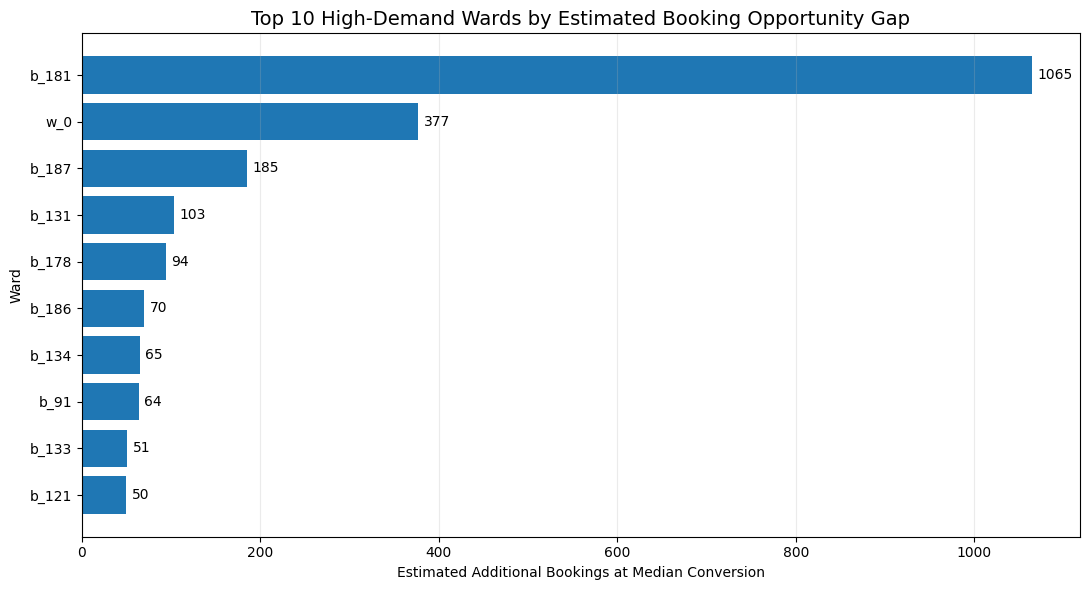

In [56]:
# ============================================================
# 7.7 Top Booking Opportunity Hotspots
# ============================================================

top10_opportunity = (
    hotspot_opportunity
    .nlargest(10, 'booking_opportunity_gap')
    .sort_values('booking_opportunity_gap')
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top10_opportunity['ward_num'],
    top10_opportunity['booking_opportunity_gap']
)

ax.bar_label(
    bars,
    fmt='%.0f',
    padding=4
)

ax.set_title(
    'Top 10 High-Demand Wards by Estimated Booking Opportunity Gap',
    fontsize=14
)

ax.set_xlabel(
    'Estimated Additional Bookings at Median Conversion'
)

ax.set_ylabel('Ward')

ax.grid(
    axis='x',
    alpha=0.25
)

plt.tight_layout()
plt.show()

The visualization makes the concentration obvious: b_181 has an estimated opportunity gap of 1,065 bookings, followed by w_0 at 377 and b_187 at 185. So the next useful question is not **“which wards are bad?”** anymore — we already know that. Now we need to **identify which stage of the booking funnel is breaking inside those wards.**

### 7.8 Funnel Bottleneck Diagnosis for Priority Wards

High demand and low overall conversion indicate that demand exists, but they do not explain where users are being lost.

To diagnose the operational bottleneck, the booking journey is decomposed into sequential funnel stages:

1. Search → E-stage availability
2. E-stage → Q-stage search
3. Q-stage search → Q-stage success
4. Q-stage success → Booking
5. Booking → Completed ride

Stage-level conversion rates help determine whether each priority ward is primarily affected by supply availability, quotation success, booking conversion, or ride completion.

In [57]:
# ============================================================
# 7.8 Funnel Bottleneck Diagnosis
# ============================================================

funnel_diag = ward_summary.copy()

# Safe percentage function
def safe_rate(numerator, denominator):
    return np.where(
        denominator > 0,
        (numerator / denominator) * 100,
        np.nan
    )

# Recalculate stage-level rates from aggregated ward counts
funnel_diag['search_to_e_rate'] = safe_rate(
    funnel_diag['srch_which_got_e'],
    funnel_diag['srch_fr_e']
)

funnel_diag['e_to_q_rate'] = safe_rate(
    funnel_diag['srch_fr_q'],
    funnel_diag['srch_which_got_e']
)

funnel_diag['q_success_rate'] = safe_rate(
    funnel_diag['srch_which_got_q'],
    funnel_diag['srch_fr_q']
)

funnel_diag['q_to_booking_rate'] = safe_rate(
    funnel_diag['booking'],
    funnel_diag['srch_which_got_q']
)

funnel_diag['booking_to_completion_rate'] = safe_rate(
    funnel_diag['done_ride'],
    funnel_diag['booking']
)

# Keep only the top 10 booking-opportunity wards
priority_wards = (
    hotspot_opportunity
    .nlargest(10, 'booking_opportunity_gap')['ward_num']
)

priority_funnel = (
    funnel_diag[
        funnel_diag['ward_num'].isin(priority_wards)
    ][
        [
            'ward_num',
            'srch_fr_e',
            'search_to_e_rate',
            'e_to_q_rate',
            'q_success_rate',
            'q_to_booking_rate',
            'booking_to_completion_rate',
            'cnvr_rate'
        ]
    ]
    .copy()
)

# Preserve opportunity ranking
priority_funnel = priority_funnel.merge(
    hotspot_opportunity[
        ['ward_num', 'booking_opportunity_gap']
    ],
    on='ward_num',
    how='left'
).sort_values(
    'booking_opportunity_gap',
    ascending=False
)

rate_cols = [
    'search_to_e_rate',
    'e_to_q_rate',
    'q_success_rate',
    'q_to_booking_rate',
    'booking_to_completion_rate',
    'cnvr_rate'
]

priority_funnel[rate_cols] = (
    priority_funnel[rate_cols].round(2)
)

display(priority_funnel)

,ward_num,srch_fr_e,search_to_e_rate,e_to_q_rate,q_success_rate,q_to_booking_rate,booking_to_completion_rate,cnvr_rate,booking_opportunity_gap
5,b_181,4862,100.00,93.01,12.38,99.29,38.85,11.44,1065.0
9,w_0,3460,99.60,76.78,83.79,35.00,47.68,22.43,377.0
7,b_187,1874,100.00,87.35,27.18,98.88,32.05,23.48,185.0
1,b_131,516,100.00,91.09,15.53,94.52,42.03,13.37,103.0
4,b_178,1119,100.00,91.42,28.84,94.58,46.24,24.93,94.0
6,b_186,1008,100.00,86.01,30.80,99.63,45.86,26.39,70.0
3,b_134,1021,99.90,71.57,38.63,97.52,36.00,26.93,65.0
8,b_91,643,100.00,79.63,35.55,82.42,48.00,23.33,64.0
2,b_133,1319,99.92,70.18,42.92,97.98,40.10,29.49,51.0
0,b_121,823,100.00,87.61,31.07,100.00,48.21,27.22,50.0


What we are tesing is :

b_181 has:
- strong Search → E performance,
- decent E → Q movement,
- but terrible Q-stage success.
Then the likely issue is not lack of demand — it is more likely related to matching/supply availability around the quote stage.

The biggest observation is that Search → E is not the problem for these priority wards: almost every ward is at roughly 100%. The major losses happen later in the funnel.

For example, b_181 has excellent early-stage flow — 100% Search→E and 93.01% E→Q — but its Q-stage success is only 12.38%. Once a Q-stage success happens, 99.29% convert to booking. That strongly suggests the critical weakness is around the Q-stage success/matching stage, not user demand or final booking intent.

b_187 shows a similar pattern: Q-stage success only 27.18%, while Q→Booking is 98.88%. b_131 is even more pronounced at 15.53% Q-stage success.

w_0, however, behaves differently. Its Q-stage success is actually high at 83.79%, but Q→Booking falls to only 35%. So w_0 appears to have a different bottleneck, which is exactly why ward-level diagnosis is useful.

Also notice that completion after booking is only around 32–48% for these wards. That may be operationally important, but before calling it abnormal we should compare it against the typical completion rate across all 244 wards.

### 7.9 Relative Funnel Bottleneck Identification

Raw stage conversion rates alone can be misleading because different stages naturally operate at different baseline conversion levels.

Therefore, each priority ward is compared with the median stage conversion rate across all wards.

For every funnel stage, the deviation from the citywide ward median is calculated. The stage with the largest negative deviation is treated as the ward's primary relative bottleneck.

This provides a more meaningful operational diagnosis than simply selecting the lowest raw percentage.

In [58]:
# ============================================================
# 7.9 Relative Funnel Bottleneck Diagnosis
# ============================================================

stage_cols = [
    'search_to_e_rate',
    'e_to_q_rate',
    'q_success_rate',
    'q_to_booking_rate',
    'booking_to_completion_rate'
]

# Median benchmark across all wards
stage_medians = funnel_diag[stage_cols].median()

print("Median funnel-stage performance across all wards:\n")
for stage, value in stage_medians.items():
    print(f"{stage}: {value:.2f}%")

# Copy priority wards
bottleneck_diag = priority_funnel.copy()

# Calculate percentage-point deviation from median
for stage in stage_cols:
    bottleneck_diag[f'{stage}_gap'] = (
        bottleneck_diag[stage] - stage_medians[stage]
    )

gap_cols = [f'{stage}_gap' for stage in stage_cols]

# Stage with largest negative deviation
bottleneck_diag['primary_bottleneck'] = (
    bottleneck_diag[gap_cols]
    .idxmin(axis=1)
    .str.replace('_gap', '', regex=False)
)

# Size of deviation
bottleneck_diag['largest_negative_gap_pp'] = (
    bottleneck_diag[gap_cols].min(axis=1).round(2)
)

display(
    bottleneck_diag[
        [
            'ward_num',
            'booking_opportunity_gap',
            'cnvr_rate',
            'primary_bottleneck',
            'largest_negative_gap_pp'
        ]
    ]
)

Median funnel-stage performance across all wards:

search_to_e_rate: 100.00%
e_to_q_rate: 65.76%
q_success_rate: 56.41%
q_to_booking_rate: 100.00%
booking_to_completion_rate: 51.56%


,ward_num,booking_opportunity_gap,cnvr_rate,primary_bottleneck,largest_negative_gap_pp
5,b_181,1065.0,11.44,q_success_rate,-44.03
9,w_0,377.0,22.43,q_to_booking_rate,-65.00
7,b_187,185.0,23.48,q_success_rate,-29.23
1,b_131,103.0,13.37,q_success_rate,-40.88
4,b_178,94.0,24.93,q_success_rate,-27.57
6,b_186,70.0,26.39,q_success_rate,-25.61
3,b_134,65.0,26.93,q_success_rate,-17.78
8,b_91,64.0,23.33,q_success_rate,-20.86
2,b_133,51.0,29.49,q_success_rate,-13.49
0,b_121,50.0,27.22,q_success_rate,-25.34


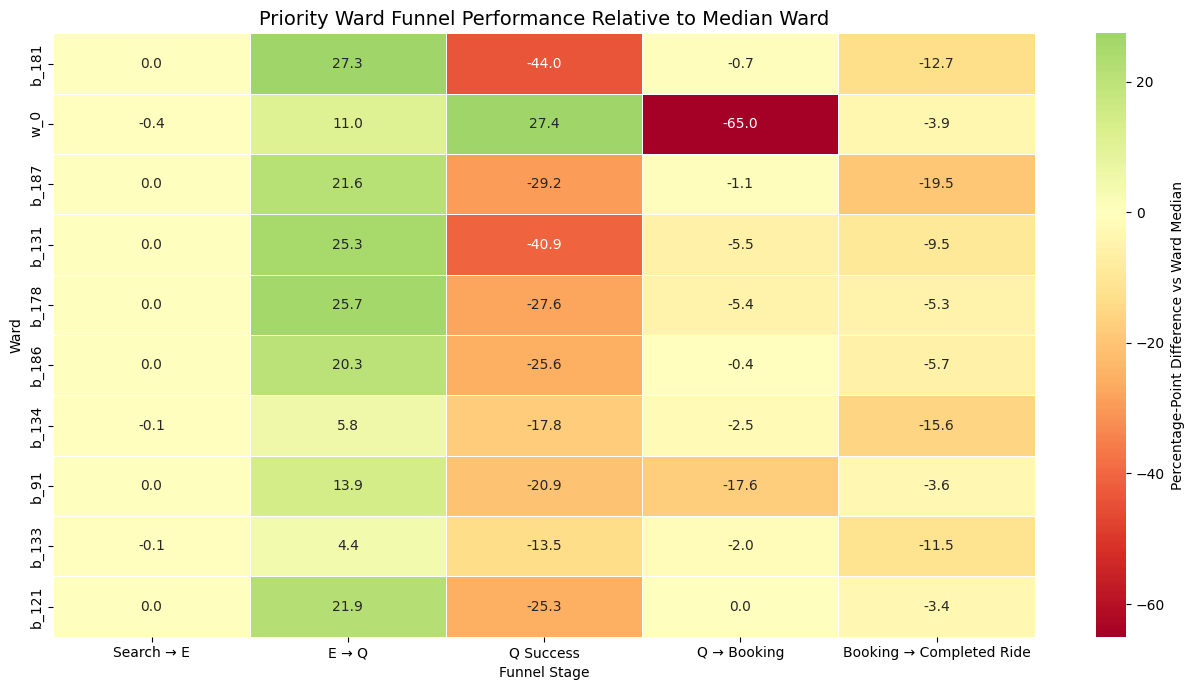

In [59]:
# ============================================================
# 7.9.1 Funnel Performance vs Ward Median Heatmap
# ============================================================

import seaborn as sns

heatmap_data = bottleneck_diag.set_index('ward_num')[
    gap_cols
].copy()

heatmap_data.columns = [
    'Search → E',
    'E → Q',
    'Q Success',
    'Q → Booking',
    'Booking → Completed Ride'
]

plt.figure(figsize=(13, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    center=0,
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Percentage-Point Difference vs Ward Median'}
)

plt.title(
    'Priority Ward Funnel Performance Relative to Median Ward',
    fontsize=14
)

plt.xlabel('Funnel Stage')
plt.ylabel('Ward')

plt.tight_layout()
plt.show()

How to read the heatmap:
- Positive value → ward performs above the median at that stage.
- Near zero → approximately normal.
- Negative value → underperformance.
- Large negative value → likely operational bottleneck.

This is much more valuable than a standard funnel chart because we'll be able to say things such as:
b_181 has exceptionally high demand and a large estimated booking opportunity, with the strongest relative weakness concentrated at the Q-stage.

while perhaps saying something completely different for w_0.

### 7.10 Operational Segmentation of Priority Wards

The relative bottleneck analysis is translated into operational investigation categories.

These recommendations should be interpreted as investigation priorities rather than confirmed causal explanations. A weak funnel stage can result from multiple operational factors and therefore requires supporting evidence from driver supply, cancellations, pricing, and temporal demand analysis.

The objective is to connect each high-opportunity ward with the operational area that should be investigated first.

In [60]:
# ============================================================
# 7.10 Operational Investigation Priorities
# ============================================================

action_map = {
    'search_to_e_rate':
        'Investigate initial service/availability coverage',

    'e_to_q_rate':
        'Investigate progression from E-stage to Q-stage',

    'q_success_rate':
        'Investigate Q-stage matching/supply availability',

    'q_to_booking_rate':
        'Investigate post-Q booking conversion',

    'booking_to_completion_rate':
        'Investigate cancellations and ride fulfilment'
}

operational_priority = bottleneck_diag[
    [
        'ward_num',
        'booking_opportunity_gap',
        'cnvr_rate',
        'primary_bottleneck',
        'largest_negative_gap_pp'
    ]
].copy()

operational_priority['investigation_priority'] = (
    operational_priority['primary_bottleneck']
    .map(action_map)
)

# Rank by estimated booking opportunity
operational_priority = operational_priority.sort_values(
    'booking_opportunity_gap',
    ascending=False
)

display(operational_priority)

,ward_num,booking_opportunity_gap,cnvr_rate,primary_bottleneck,largest_negative_gap_pp,investigation_priority
5,b_181,1065.0,11.44,q_success_rate,-44.03,Investigate Q-stage matching/supply availability
9,w_0,377.0,22.43,q_to_booking_rate,-65.00,Investigate post-Q booking conversion
7,b_187,185.0,23.48,q_success_rate,-29.23,Investigate Q-stage matching/supply availability
1,b_131,103.0,13.37,q_success_rate,-40.88,Investigate Q-stage matching/supply availability
4,b_178,94.0,24.93,q_success_rate,-27.57,Investigate Q-stage matching/supply availability
6,b_186,70.0,26.39,q_success_rate,-25.61,Investigate Q-stage matching/supply availability
3,b_134,65.0,26.93,q_success_rate,-17.78,Investigate Q-stage matching/supply availability
8,b_91,64.0,23.33,q_success_rate,-20.86,Investigate Q-stage matching/supply availability
2,b_133,51.0,29.49,q_success_rate,-13.49,Investigate Q-stage matching/supply availability
0,b_121,50.0,27.22,q_success_rate,-25.34,Investigate Q-stage matching/supply availability


In [61]:
# ============================================================
# 7.10.1 Opportunity by Primary Bottleneck
# ============================================================

bottleneck_summary = (
    operational_priority
    .groupby('primary_bottleneck')
    .agg(
        priority_wards=('ward_num', 'count'),
        estimated_booking_opportunity=('booking_opportunity_gap', 'sum')
    )
    .reset_index()
    .sort_values(
        'estimated_booking_opportunity',
        ascending=False
    )
)

display(bottleneck_summary)

,primary_bottleneck,priority_wards,estimated_booking_opportunity
0,q_success_rate,9,1747.0
1,q_to_booking_rate,1,377.0


High-demand wards do not share one universal failure mode. Most high-opportunity wards show substantial underperformance at Q-stage success, while w_0 represents a distinct post-Q booking conversion problem. Therefore, operational intervention should be targeted by funnel bottleneck rather than applied uniformly across Bangalore.


Your top-10 priority wards account for an estimated 2,124 bookings of opportunity. Of that:
- 9 wards have q_success_rate as the primary relative bottleneck
- Those 9 wards contribute 1,747 estimated bookings of opportunity
- w_0 is the only exception, with q_to_booking_rate as the main bottleneck
- w_0 contributes another 377
So around 82% of the top-10 opportunity is concentrated in wards whose strongest relative weakness is Q-stage success.

### 7.11 Ward-Level Funnel Analysis — Key Findings

The ward-level analysis identified substantial geographic variation in demand and booking conversion.

Key findings:

- The 75th-percentile search-demand threshold was 117.75 searches, while the median ward search-to-booking conversion rate was 33.33%.
- 35 wards were classified as high-demand, low-conversion hotspots.
- These hotspot wards represented an estimated booking opportunity gap of approximately 2,443 bookings if their conversion performance reached the median ward benchmark.
- The opportunity was highly concentrated. Ward `b_181` alone contributed an estimated 1,065-booking gap, followed by `w_0` with 377 and `b_187` with 185.
- Funnel-stage benchmarking showed that initial Search → E availability was generally not the dominant problem in priority wards.
- 9 of the top 10 opportunity wards showed their largest relative underperformance at the Q-stage success step.
- Across these 9 wards, the estimated booking opportunity was approximately 1,747 bookings.
- `w_0` displayed a different pattern: Q-stage success was comparatively strong, while Q → Booking conversion was substantially below the median benchmark.
- Several wards also showed below-median Booking → Completed Ride performance, suggesting that fulfilment and cancellation behaviour should be investigated separately.

Overall, the results indicate that high-demand wards do not share a single operational failure mode. Most priority wards require investigation of Q-stage matching/supply conditions, while some wards exhibit downstream booking or fulfilment issues.

These findings identify operational investigation priorities rather than confirmed causal explanations. Driver supply, temporal demand patterns, cancellations, and other operational variables must be analysed before attributing the observed funnel losses to specific causes.

## 8. Driver Supply & Availability Analysis

The ward-level funnel analysis identified several high-demand areas with substantial Q-stage underperformance.

The next step examines driver-side supply patterns to determine whether driver availability may help explain these geographic funnel bottlenecks.

The analysis begins by validating the driver-supply dataset, its available metrics, distributions, and geographic identifiers before linking supply conditions with ward-level demand and conversion performance.

In [62]:
# ============================================================
# 8.1 Driver Supply Dataset Inspection
# ============================================================

print("Driver supply shape:", driver_supply.shape)

print("\nColumns:")
print(driver_supply.columns.tolist())

print("\nData types:")
display(driver_supply.dtypes.to_frame('dtype'))

print("\nFirst 10 rows:")
display(driver_supply.head(10))

print("\nMissing values:")
display(
    driver_supply.isna()
    .sum()
    .to_frame('missing_count')
)

print("\nUnique values per column:")
display(
    driver_supply.nunique()
    .to_frame('unique_values')
)

print("\nNumeric summary:")
display(
    driver_supply.describe(include='all').T
)

Driver supply shape: (486, 6)

Columns:
['ward_num', 'active', 'vehicle_type', 'active_drvr', 'drvr_notonride', 'drvr_onride']

Data types:


,dtype
ward_num,object
active,bool
vehicle_type,object
active_drvr,int64
drvr_notonride,int64
drvr_onride,int64



First 10 rows:


,ward_num,active,vehicle_type,active_drvr,drvr_notonride,drvr_onride
0,b_1,True,Auto,181,172,9
1,b_1,True,Cab,155,141,14
2,b_2,True,Auto,61,58,3
3,b_2,True,Cab,39,37,2
4,b_3,True,Auto,97,91,6
5,b_3,True,Cab,41,38,3
6,b_4,True,Auto,129,119,10
7,b_4,True,Cab,46,45,1
8,b_5,True,Auto,153,143,10
9,b_5,True,Cab,72,71,1



Missing values:


,missing_count
ward_num,0
active,0
vehicle_type,0
active_drvr,0
drvr_notonride,0
drvr_onride,0



Unique values per column:


,unique_values
ward_num,244
active,1
vehicle_type,2
active_drvr,192
drvr_notonride,180
drvr_onride,62



Numeric summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ward_num,486,244,b_1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
active,486,1,True,486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,486,2,Auto,244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
active_drvr,486.0,NaN,NaN,NaN,100.742798,287.103799,1.0,26.25,53.0,109.0,5109.0
drvr_notonride,486.0,NaN,NaN,NaN,87.041152,272.441596,0.0,21.0,45.5,92.0,4921.0
drvr_onride,486.0,NaN,NaN,NaN,13.701646,20.671497,0.0,2.0,7.0,16.75,196.0


### 8.2 Driver Supply Structural Validation

Before analysing driver availability, the driver-supply table is validated at the ward–vehicle level.

The checks include:

- uniqueness of the ward and vehicle-type combination,
- coverage of Auto and Cab across wards,
- consistency between total active drivers and the on-ride / not-on-ride components,
- alignment of driver-supply ward identifiers with the ward-funnel dataset,
- and inspection of unusually large driver counts.

Missing ward–vehicle combinations are treated as missing records unless there is evidence that they represent true zero-driver observations.

In [63]:
# ============================================================
# 8.2 Driver Supply Structural Validation
# ============================================================

# 1. Vehicle-type frequency
print("Rows by vehicle type:")
print(driver_supply['vehicle_type'].value_counts())

# ------------------------------------------------------------

# 2. Duplicate ward + vehicle combinations
duplicate_pairs = driver_supply.duplicated(
    subset=['ward_num', 'vehicle_type'],
    keep=False
)

print(
    "\nDuplicate ward-vehicle rows:",
    duplicate_pairs.sum()
)

if duplicate_pairs.any():
    display(
        driver_supply[
            duplicate_pairs
        ].sort_values(['ward_num', 'vehicle_type'])
    )

# ------------------------------------------------------------

# 3. Identify missing ward-vehicle combinations

wards = sorted(driver_supply['ward_num'].unique())
vehicles = sorted(driver_supply['vehicle_type'].unique())

expected_pairs = pd.MultiIndex.from_product(
    [wards, vehicles],
    names=['ward_num', 'vehicle_type']
).to_frame(index=False)

actual_pairs = driver_supply[
    ['ward_num', 'vehicle_type']
].drop_duplicates()

missing_pairs = (
    expected_pairs
    .merge(
        actual_pairs,
        on=['ward_num', 'vehicle_type'],
        how='left',
        indicator=True
    )
    .query("_merge == 'left_only'")
    .drop(columns='_merge')
)

print(
    "\nExpected ward-vehicle combinations:",
    len(expected_pairs)
)

print(
    "Actual ward-vehicle combinations:",
    len(actual_pairs)
)

print(
    "Missing combinations:",
    len(missing_pairs)
)

display(missing_pairs)

# ------------------------------------------------------------

# 4. Validate driver-count relationship

driver_supply_check = driver_supply.copy()

driver_supply_check['component_sum'] = (
    driver_supply_check['drvr_notonride']
    + driver_supply_check['drvr_onride']
)

driver_supply_check['count_difference'] = (
    driver_supply_check['active_drvr']
    - driver_supply_check['component_sum']
)

print(
    "\nRows where active_drvr != "
    "drvr_notonride + drvr_onride:",
    (driver_supply_check['count_difference'] != 0).sum()
)

display(
    driver_supply_check[
        driver_supply_check['count_difference'] != 0
    ]
)

# ------------------------------------------------------------

# 5. Check ward alignment with ward funnel analysis

supply_wards = set(driver_supply['ward_num'])
funnel_wards = set(ward_summary['ward_num'])

print(
    "\nWards in driver supply but not funnel:",
    supply_wards - funnel_wards
)

print(
    "Wards in funnel but not driver supply:",
    funnel_wards - supply_wards
)

# ------------------------------------------------------------

# 6. Inspect largest supply observations

print("\nTop 15 rows by active driver count:")

display(
    driver_supply
    .sort_values('active_drvr', ascending=False)
    .head(15)
)

Rows by vehicle type:
vehicle_type
Auto    244
Cab     242
Name: count, dtype: int64

Duplicate ward-vehicle rows: 0

Expected ward-vehicle combinations: 488
Actual ward-vehicle combinations: 486
Missing combinations: 2


,ward_num,vehicle_type
127,b_156,Cab
437,b_77,Cab



Rows where active_drvr != drvr_notonride + drvr_onride: 0


,ward_num,active,vehicle_type,active_drvr,drvr_notonride,drvr_onride,component_sum,count_difference



Wards in driver supply but not funnel: set()
Wards in funnel but not driver supply: set()

Top 15 rows by active driver count:


,ward_num,active,vehicle_type,active_drvr,drvr_notonride,drvr_onride
485,w_0,True,Cab,5109,4921,188
484,w_0,True,Auto,3410,3214,196
106,b_114,True,Auto,629,529,100
324,b_116,True,Auto,525,470,55
104,b_115,True,Auto,497,453,44
374,b_128,True,Auto,432,339,93
172,b_181,True,Auto,426,281,145
314,b_110,True,Auto,410,353,57
265,b_8,True,Auto,387,332,55
120,b_129,True,Auto,379,270,109


### 8.3 Driver Availability and Utilization Metrics

Driver counts alone do not indicate whether supply is immediately available to satisfy new demand.

Two operational ratios are therefore derived for each ward–vehicle combination:

- **Available driver share:** percentage of active drivers who are currently not on a ride.
- **On-ride utilization share:** percentage of active drivers who are currently serving a ride.

Because active drivers are exactly decomposed into not-on-ride and on-ride drivers, these two percentages should sum to approximately 100%.

The two missing Cab records (`b_156` and `b_77`) are retained as missing information rather than assumed to represent zero Cab supply.

In [64]:
# ============================================================
# 8.3 Driver Availability & Utilization Metrics
# ============================================================

driver_metrics = driver_supply.copy()

driver_metrics['available_driver_pct'] = (
    driver_metrics['drvr_notonride']
    / driver_metrics['active_drvr']
    * 100
)

driver_metrics['onride_utilization_pct'] = (
    driver_metrics['drvr_onride']
    / driver_metrics['active_drvr']
    * 100
)

driver_metrics['share_check'] = (
    driver_metrics['available_driver_pct']
    + driver_metrics['onride_utilization_pct']
)

print(
    "Rows where availability + utilization "
    "does not approximately equal 100%:",
    (~np.isclose(
        driver_metrics['share_check'],
        100,
        atol=0.01
    )).sum()
)

print("\nAvailability/utilization summary:")

display(
    driver_metrics[
        [
            'active_drvr',
            'available_driver_pct',
            'onride_utilization_pct'
        ]
    ].describe().round(2)
)

print("\nMedian metrics by vehicle type:")

vehicle_supply_summary = (
    driver_metrics
    .groupby('vehicle_type')
    .agg(
        wards=('ward_num', 'count'),
        median_active_drivers=('active_drvr', 'median'),
        median_available_pct=('available_driver_pct', 'median'),
        median_utilization_pct=('onride_utilization_pct', 'median')
    )
    .round(2)
)

display(vehicle_supply_summary)

Rows where availability + utilization does not approximately equal 100%: 0

Availability/utilization summary:


,active_drvr,available_driver_pct,onride_utilization_pct
count,486.00,486.00,486.00
mean,100.74,85.08,14.92
std,287.10,12.13,12.13
min,1.00,0.00,0.00
25%,26.25,78.08,6.16
50%,53.00,86.87,13.13
75%,109.00,93.84,21.92
max,5109.00,100.00,100.00



Median metrics by vehicle type:


,wards,median_active_drivers,median_available_pct,median_utilization_pct
vehicle_type,,,,
Auto,244,87.5,84.26,15.74
Cab,242,30.0,89.73,10.27


In [65]:
# ============================================================
# 8.3.1 Ward-Level Driver Supply Summary
# ============================================================

ward_supply = (
    driver_metrics
    .groupby('ward_num')
    .agg(
        vehicle_records=('vehicle_type', 'nunique'),
        total_active_drivers=('active_drvr', 'sum'),
        available_drivers=('drvr_notonride', 'sum'),
        onride_drivers=('drvr_onride', 'sum')
    )
    .reset_index()
)

ward_supply['complete_vehicle_coverage'] = (
    ward_supply['vehicle_records'] == 2
)

ward_supply['available_driver_pct'] = (
    ward_supply['available_drivers']
    / ward_supply['total_active_drivers']
    * 100
)

ward_supply['onride_utilization_pct'] = (
    ward_supply['onride_drivers']
    / ward_supply['total_active_drivers']
    * 100
)

print("Ward supply shape:", ward_supply.shape)

print(
    "Wards with complete Auto + Cab coverage:",
    ward_supply['complete_vehicle_coverage'].sum()
)

print(
    "Wards with incomplete vehicle coverage:",
    (~ward_supply['complete_vehicle_coverage']).sum()
)

print("\nIncomplete wards:")

display(
    ward_supply[
        ~ward_supply['complete_vehicle_coverage']
    ]
)

print("\nTop 15 wards by total active drivers:")

display(
    ward_supply
    .sort_values(
        'total_active_drivers',
        ascending=False
    )
    .head(15)
)

Ward supply shape: (244, 8)
Wards with complete Auto + Cab coverage: 242
Wards with incomplete vehicle coverage: 2

Incomplete wards:


,ward_num,vehicle_records,total_active_drivers,available_drivers,onride_drivers,complete_vehicle_coverage,available_driver_pct,onride_utilization_pct
63,b_156,1,16,14,2,False,87.5,12.5
218,b_77,1,1,1,0,False,100.0,0.0



Top 15 wards by total active drivers:


,ward_num,vehicle_records,total_active_drivers,available_drivers,onride_drivers,complete_vehicle_coverage,available_driver_pct,onride_utilization_pct
243,w_0,2,8519,8135,384,True,95.492429,4.507571
17,b_114,2,892,745,147,True,83.520179,16.479821
19,b_116,2,835,757,78,True,90.658683,9.341317
18,b_115,2,752,682,70,True,90.691489,9.308511
91,b_181,2,686,480,206,True,69.970845,30.029155
32,b_128,2,628,511,117,True,81.369427,18.630573
13,b_110,2,598,519,79,True,86.789298,13.210702
221,b_8,2,571,509,62,True,89.141856,10.858144
8,b_106,2,554,497,57,True,89.711191,10.288809
10,b_108,2,547,477,70,True,87.202925,12.797075


## 8.4 Supply–Demand Alignment at Ward Level

The previous sections analyzed demand/funnel performance and driver supply independently.

In this section, ward-level demand and funnel metrics are combined with driver-supply metrics to determine whether poor conversion is associated with insufficient driver availability, high driver utilization, or other matching/funnel inefficiencies.

Key questions:

1. Do high-demand wards have sufficient active and available driver supply?
2. Which wards experience the greatest demand pressure relative to available drivers?
3. Are the previously identified high-demand, low-conversion opportunity wards also supply constrained?
4. Is low Q-stage success associated with driver availability or utilization?

In [66]:
# ============================================================
# 8.4 Supply–Demand Alignment at Ward Level
# ============================================================

import numpy as np

# Validate uniqueness before merging
print("Unique wards in ward_summary:", ward_summary["ward_num"].nunique())
print("Unique wards in ward_supply :", ward_supply["ward_num"].nunique())

print(
    "Duplicate wards in ward_summary:",
    ward_summary["ward_num"].duplicated().sum()
)

print(
    "Duplicate wards in ward_supply:",
    ward_supply["ward_num"].duplicated().sum()
)

# Merge demand/funnel metrics with driver-supply metrics
supply_demand = ward_summary.merge(
    ward_supply,
    on="ward_num",
    how="left",
    validate="one_to_one"
)

print("\nSupply-demand shape:", supply_demand.shape)

print(
    "Wards missing driver-supply information:",
    supply_demand["total_active_drivers"].isna().sum()
)

display(
    supply_demand[
        [
            "ward_num",
            "srch_fr_e",
            "srch_fr_q",
            "booking",
            "done_ride",
            "cnvr_rate",
            "total_active_drivers",
            "available_drivers",
            "onride_drivers",
            "available_driver_pct",
            "onride_utilization_pct",
            "complete_vehicle_coverage"
        ]
    ].head(10)
)

Unique wards in ward_summary: 244
Unique wards in ward_supply : 244
Duplicate wards in ward_summary: 0
Duplicate wards in ward_supply: 0

Supply-demand shape: (244, 28)
Wards missing driver-supply information: 0


,ward_num,srch_fr_e,srch_fr_q,booking,done_ride,cnvr_rate,total_active_drivers,available_drivers,onride_drivers,available_driver_pct,onride_utilization_pct,complete_vehicle_coverage
0,b_1,72,39,19,12,26.388889,336,313,23,93.154762,6.845238,True
1,b_10,188,139,65,32,34.574468,491,399,92,81.262729,18.737271,True
2,b_100,159,129,56,37,35.220126,297,217,80,73.063973,26.936027,True
3,b_101,43,29,19,5,44.186047,86,60,26,69.767442,30.232558,True
4,b_102,127,110,50,23,39.370079,87,64,23,73.563218,26.436782,True
5,b_103,172,140,70,37,40.697674,117,81,36,69.230769,30.769231,True
6,b_104,70,51,21,7,30.000000,106,96,10,90.566038,9.433962,True
7,b_105,436,336,117,62,26.834862,463,414,49,89.416847,10.583153,True
8,b_106,216,155,77,43,35.648148,554,497,57,89.711191,10.288809,True
9,b_107,70,42,24,11,34.285714,238,223,15,93.697479,6.302521,True


In [67]:
# ------------------------------------------------------------
# Driver supply pressure metrics
# ------------------------------------------------------------

supply_demand["searches_per_active_driver"] = np.where(
    supply_demand["total_active_drivers"] > 0,
    supply_demand["srch_fr_e"] / supply_demand["total_active_drivers"],
    np.nan
)

supply_demand["searches_per_available_driver"] = np.where(
    supply_demand["available_drivers"] > 0,
    supply_demand["srch_fr_e"] / supply_demand["available_drivers"],
    np.nan
)

supply_demand["q_requests_per_available_driver"] = np.where(
    supply_demand["available_drivers"] > 0,
    supply_demand["srch_fr_q"] / supply_demand["available_drivers"],
    np.nan
)

supply_demand["bookings_per_available_driver"] = np.where(
    supply_demand["available_drivers"] > 0,
    supply_demand["booking"] / supply_demand["available_drivers"],
    np.nan
)

print("Demand-pressure summary:")

display(
    supply_demand[
        [
            "searches_per_active_driver",
            "searches_per_available_driver",
            "q_requests_per_available_driver",
            "bookings_per_available_driver",
            "available_driver_pct",
            "onride_utilization_pct"
        ]
    ].describe().round(2)
)

Demand-pressure summary:


,searches_per_active_driver,searches_per_available_driver,q_requests_per_available_driver,bookings_per_available_driver,available_driver_pct,onride_utilization_pct
count,244.00,244.00,244.00,244.00,244.00,244.00
mean,0.72,0.89,0.65,0.28,84.32,15.68
std,0.96,1.17,1.03,0.35,9.24,9.24
min,0.04,0.04,0.00,0.00,55.00,0.00
25%,0.28,0.31,0.18,0.11,78.98,8.47
50%,0.44,0.54,0.32,0.19,86.06,13.94
75%,0.79,1.01,0.68,0.33,91.53,21.02
max,9.00,10.13,9.42,4.00,100.00,45.00


In [68]:
# ------------------------------------------------------------
# Wards with highest demand pressure on available drivers
# ------------------------------------------------------------

high_supply_pressure = (
    supply_demand[
        [
            "ward_num",
            "srch_fr_e",
            "booking",
            "cnvr_rate",
            "total_active_drivers",
            "available_drivers",
            "available_driver_pct",
            "onride_utilization_pct",
            "searches_per_available_driver",
            "q_requests_per_available_driver"
        ]
    ]
    .sort_values(
        "searches_per_available_driver",
        ascending=False
    )
    .head(15)
)

print("Top 15 wards by searches per available driver:")

display(
    high_supply_pressure.round(2)
)

Top 15 wards by searches per available driver:


,ward_num,srch_fr_e,booking,cnvr_rate,total_active_drivers,available_drivers,available_driver_pct,onride_utilization_pct,searches_per_available_driver,q_requests_per_available_driver
91,b_181,4862,556,11.44,686,480,69.97,30.03,10.13,9.42
218,b_77,9,4,44.44,1,1,100.00,0.00,9.00,8.00
97,b_187,1874,440,23.48,382,319,83.51,16.49,5.87,5.13
95,b_185,428,144,33.64,105,82,78.10,21.90,5.22,4.38
39,b_134,1021,275,26.93,277,245,88.45,11.55,4.17,2.98
25,b_121,823,224,27.22,258,206,79.84,20.16,4.00,3.50
87,b_178,1119,279,24.93,340,293,86.18,13.82,3.82,3.49
86,b_177,246,60,24.39,106,71,66.98,33.02,3.46,2.75
99,b_189,396,121,30.56,162,117,72.22,27.78,3.38,2.75
240,b_97,51,14,27.45,21,16,76.19,23.81,3.19,2.75


### 8.4.1 Data-Quality Adjustment for Supply-Pressure Ranking

Two wards (`b_156` and `b_77`) do not have complete Auto + Cab driver-supply coverage.

Although their calculated pressure metrics are mathematically valid for the available records, they are not directly comparable with wards that have complete vehicle coverage.

Therefore:

- All 244 wards are retained in the merged dataset.
- Wards with incomplete vehicle coverage are explicitly flagged.
- Comparative supply-pressure rankings use only wards with complete vehicle coverage.

In [69]:
# ------------------------------------------------------------
# Restrict comparative ranking to complete vehicle coverage
# ------------------------------------------------------------

incomplete_supply_wards = supply_demand[
    ~supply_demand["complete_vehicle_coverage"]
].copy()

print("Wards excluded from comparative supply ranking:")
display(
    incomplete_supply_wards[
        [
            "ward_num",
            "total_active_drivers",
            "available_drivers",
            "searches_per_available_driver",
            "complete_vehicle_coverage"
        ]
    ].round(2)
)

supply_demand_valid = supply_demand[
    supply_demand["complete_vehicle_coverage"]
].copy()

print("\nWards retained for reliable comparison:", len(supply_demand_valid))

reliable_pressure_ranking = (
    supply_demand_valid[
        [
            "ward_num",
            "srch_fr_e",
            "booking",
            "cnvr_rate",
            "q_accept_rate",
            "total_active_drivers",
            "available_drivers",
            "available_driver_pct",
            "onride_utilization_pct",
            "searches_per_available_driver",
            "q_requests_per_available_driver"
        ]
    ]
    .sort_values("searches_per_available_driver", ascending=False)
    .head(15)
)

print("\nTop 15 reliable supply-pressure wards:")
display(reliable_pressure_ranking.round(2))

Wards excluded from comparative supply ranking:


,ward_num,total_active_drivers,available_drivers,searches_per_available_driver,complete_vehicle_coverage
63,b_156,16,14,0.29,False
218,b_77,1,1,9.00,False



Wards retained for reliable comparison: 242

Top 15 reliable supply-pressure wards:


,ward_num,srch_fr_e,booking,cnvr_rate,q_accept_rate,total_active_drivers,available_drivers,available_driver_pct,onride_utilization_pct,searches_per_available_driver,q_requests_per_available_driver
91,b_181,4862,556,11.44,12.38,686,480,69.97,30.03,10.13,9.42
97,b_187,1874,440,23.48,27.18,382,319,83.51,16.49,5.87,5.13
95,b_185,428,144,33.64,41.23,105,82,78.10,21.90,5.22,4.38
39,b_134,1021,275,26.93,38.63,277,245,88.45,11.55,4.17,2.98
25,b_121,823,224,27.22,31.07,258,206,79.84,20.16,4.00,3.50
87,b_178,1119,279,24.93,28.84,340,293,86.18,13.82,3.82,3.49
86,b_177,246,60,24.39,30.77,106,71,66.98,33.02,3.46,2.75
99,b_189,396,121,30.56,41.61,162,117,72.22,27.78,3.38,2.75
240,b_97,51,14,27.45,36.36,21,16,76.19,23.81,3.19,2.75
38,b_133,1319,389,29.49,42.92,502,428,85.26,14.74,3.08,2.16


### 8.4.2 Driver-Supply Conditions in High-Opportunity Wards

The ward-level funnel analysis identified 35 high-demand, low-conversion wards with an estimated booking opportunity gap.

This section combines those opportunity wards with driver-supply metrics to determine whether their conversion problems are associated with:

- low driver availability,
- high driver utilization,
- high demand pressure per available driver,
- or funnel/matching inefficiencies despite adequate supply.

This distinction is critical because different problems require different operational interventions.

In [70]:
# ============================================================
# 8.4.2 Supply conditions in high-opportunity wards
# ============================================================

opportunity_supply = supply_demand.merge(
    operational_priority[
        [
            "ward_num",
            "booking_opportunity_gap",
            "primary_bottleneck",
            "investigation_priority"
        ]
    ],
    on="ward_num",
    how="inner",
    validate="one_to_one"
)

opportunity_supply = opportunity_supply.sort_values(
    "booking_opportunity_gap",
    ascending=False
)

print("Opportunity wards matched with supply data:", len(opportunity_supply))

print(
    "Total booking opportunity gap:",
    round(opportunity_supply["booking_opportunity_gap"].sum())
)

print(
    "Opportunity wards with incomplete vehicle coverage:",
    (~opportunity_supply["complete_vehicle_coverage"]).sum()
)

display(
    opportunity_supply[
        [
            "ward_num",
            "srch_fr_e",
            "q_accept_rate",
            "cnvr_rate",
            "total_active_drivers",
            "available_drivers",
            "available_driver_pct",
            "onride_utilization_pct",
            "searches_per_available_driver",
            "q_requests_per_available_driver",
            "booking_opportunity_gap",
            "primary_bottleneck",
            "investigation_priority",
            "complete_vehicle_coverage"
        ]
    ].head(15).round(2)
)

Opportunity wards matched with supply data: 10
Total booking opportunity gap: 2124
Opportunity wards with incomplete vehicle coverage: 0


,ward_num,srch_fr_e,q_accept_rate,cnvr_rate,total_active_drivers,available_drivers,available_driver_pct,onride_utilization_pct,searches_per_available_driver,q_requests_per_available_driver,booking_opportunity_gap,primary_bottleneck,investigation_priority,complete_vehicle_coverage
5,b_181,4862,12.38,11.44,686,480,69.97,30.03,10.13,9.42,1065.0,q_success_rate,Investigate Q-stage matching/supply availability,True
9,w_0,3460,83.79,22.43,8519,8135,95.49,4.51,0.43,0.33,377.0,q_to_booking_rate,Investigate post-Q booking conversion,True
7,b_187,1874,27.18,23.48,382,319,83.51,16.49,5.87,5.13,185.0,q_success_rate,Investigate Q-stage matching/supply availability,True
1,b_131,516,15.53,13.37,262,193,73.66,26.34,2.67,2.44,103.0,q_success_rate,Investigate Q-stage matching/supply availability,True
4,b_178,1119,28.84,24.93,340,293,86.18,13.82,3.82,3.49,94.0,q_success_rate,Investigate Q-stage matching/supply availability,True
6,b_186,1008,30.80,26.39,478,400,83.68,16.32,2.52,2.17,70.0,q_success_rate,Investigate Q-stage matching/supply availability,True
3,b_134,1021,38.63,26.93,277,245,88.45,11.55,4.17,2.98,65.0,q_success_rate,Investigate Q-stage matching/supply availability,True
8,b_91,643,35.55,23.33,373,282,75.60,24.40,2.28,1.82,64.0,q_success_rate,Investigate Q-stage matching/supply availability,True
2,b_133,1319,42.92,29.49,502,428,85.26,14.74,3.08,2.16,51.0,q_success_rate,Investigate Q-stage matching/supply availability,True
0,b_121,823,31.07,27.22,258,206,79.84,20.16,4.00,3.50,50.0,q_success_rate,Investigate Q-stage matching/supply availability,True


In [71]:
# ============================================================
# Rebuild FULL high-demand, low-conversion opportunity set
# ============================================================

# Recalculate original Section 7 thresholds
demand_threshold = ward_summary["srch_fr_e"].quantile(0.75)
conversion_benchmark = ward_summary["cnvr_rate"].median()

print("75th-percentile demand threshold:", round(demand_threshold, 2))
print("Median ward conversion benchmark:", round(conversion_benchmark, 2))

# Full opportunity set
all_opportunity_wards = ward_summary[
    (ward_summary["srch_fr_e"] > demand_threshold) &
    (ward_summary["cnvr_rate"] < conversion_benchmark)
].copy()

# Estimated bookings if ward converted at median benchmark
all_opportunity_wards["expected_bookings_at_median"] = (
    all_opportunity_wards["srch_fr_e"]
    * conversion_benchmark / 100
)

# Estimated recoverable booking gap
all_opportunity_wards["booking_opportunity_gap"] = (
    all_opportunity_wards["expected_bookings_at_median"]
    - all_opportunity_wards["booking"]
).clip(lower=0).round()

all_opportunity_wards = all_opportunity_wards.sort_values(
    "booking_opportunity_gap",
    ascending=False
)

print("\nNumber of opportunity wards:", len(all_opportunity_wards))
print(
    "Total estimated booking opportunity gap:",
    int(all_opportunity_wards["booking_opportunity_gap"].sum())
)

display(
    all_opportunity_wards[
        [
            "ward_num",
            "srch_fr_e",
            "booking",
            "cnvr_rate",
            "expected_bookings_at_median",
            "booking_opportunity_gap"
        ]
    ].head(15).round(2)
)

75th-percentile demand threshold: 117.75
Median ward conversion benchmark: 33.33

Number of opportunity wards: 35
Total estimated booking opportunity gap: 2443


,ward_num,srch_fr_e,booking,cnvr_rate,expected_bookings_at_median,booking_opportunity_gap
91,b_181,4862,556,11.44,1620.67,1065.0
243,w_0,3460,776,22.43,1153.33,377.0
97,b_187,1874,440,23.48,624.67,185.0
36,b_131,516,69,13.37,172.00,103.0
87,b_178,1119,279,24.93,373.00,94.0
96,b_186,1008,266,26.39,336.00,70.0
39,b_134,1021,275,26.93,340.33,65.0
234,b_91,643,150,23.33,214.33,64.0
38,b_133,1319,389,29.49,439.67,51.0
25,b_121,823,224,27.22,274.33,50.0


In [72]:
# ============================================================
# Merge FULL opportunity set with driver supply
# ============================================================

opportunity_supply = all_opportunity_wards.merge(
    ward_supply,
    on="ward_num",
    how="left",
    validate="one_to_one"
)

# Recreate pressure metrics
opportunity_supply["searches_per_active_driver"] = np.where(
    opportunity_supply["total_active_drivers"] > 0,
    opportunity_supply["srch_fr_e"]
    / opportunity_supply["total_active_drivers"],
    np.nan
)

opportunity_supply["searches_per_available_driver"] = np.where(
    opportunity_supply["available_drivers"] > 0,
    opportunity_supply["srch_fr_e"]
    / opportunity_supply["available_drivers"],
    np.nan
)

opportunity_supply["q_requests_per_available_driver"] = np.where(
    opportunity_supply["available_drivers"] > 0,
    opportunity_supply["srch_fr_q"]
    / opportunity_supply["available_drivers"],
    np.nan
)

opportunity_supply = opportunity_supply.sort_values(
    "booking_opportunity_gap",
    ascending=False
)

print("Opportunity wards matched with supply data:",
      len(opportunity_supply))

print(
    "Total booking opportunity gap:",
    int(opportunity_supply["booking_opportunity_gap"].sum())
)

print(
    "Opportunity wards with incomplete vehicle coverage:",
    (~opportunity_supply["complete_vehicle_coverage"]).sum()
)

display(
    opportunity_supply[
        [
            "ward_num",
            "srch_fr_e",
            "q_accept_rate",
            "cnvr_rate",
            "total_active_drivers",
            "available_drivers",
            "available_driver_pct",
            "onride_utilization_pct",
            "searches_per_available_driver",
            "q_requests_per_available_driver",
            "booking_opportunity_gap",
            "complete_vehicle_coverage"
        ]
    ].head(15).round(2)
)

Opportunity wards matched with supply data: 35
Total booking opportunity gap: 2443
Opportunity wards with incomplete vehicle coverage: 0


,ward_num,srch_fr_e,q_accept_rate,cnvr_rate,total_active_drivers,available_drivers,available_driver_pct,onride_utilization_pct,searches_per_available_driver,q_requests_per_available_driver,booking_opportunity_gap,complete_vehicle_coverage
0,b_181,4862,12.38,11.44,686,480,69.97,30.03,10.13,9.42,1065.0,True
1,w_0,3460,83.79,22.43,8519,8135,95.49,4.51,0.43,0.33,377.0,True
2,b_187,1874,27.18,23.48,382,319,83.51,16.49,5.87,5.13,185.0,True
3,b_131,516,15.53,13.37,262,193,73.66,26.34,2.67,2.44,103.0,True
4,b_178,1119,28.84,24.93,340,293,86.18,13.82,3.82,3.49,94.0,True
5,b_186,1008,30.80,26.39,478,400,83.68,16.32,2.52,2.17,70.0,True
6,b_134,1021,38.63,26.93,277,245,88.45,11.55,4.17,2.98,65.0,True
7,b_91,643,35.55,23.33,373,282,75.60,24.40,2.28,1.82,64.0,True
8,b_133,1319,42.92,29.49,502,428,85.26,14.74,3.08,2.16,51.0,True
9,b_121,823,31.07,27.22,258,206,79.84,20.16,4.00,3.50,50.0,True


### 8.4.3 Opportunity Wards vs Other Wards

To determine whether high-demand, low-conversion wards systematically experience greater driver-supply pressure, supply metrics are compared between:

- the 35 identified opportunity wards, and
- wards not classified as high-demand, low-conversion opportunities.

Median values are used because several pressure metrics are strongly skewed by extreme wards such as `b_181`.

In [73]:
# ============================================================
# 8.4.3 Opportunity wards vs non-opportunity wards
# ============================================================

opportunity_ids = set(all_opportunity_wards["ward_num"])

valid_opportunity_supply = supply_demand_valid[
    supply_demand_valid["ward_num"].isin(opportunity_ids)
].copy()

valid_non_opportunity_supply = supply_demand_valid[
    ~supply_demand_valid["ward_num"].isin(opportunity_ids)
].copy()

print("Valid opportunity wards:", len(valid_opportunity_supply))
print("Valid non-opportunity wards:", len(valid_non_opportunity_supply))

metrics_to_compare = [
    "searches_per_available_driver",
    "q_requests_per_available_driver",
    "available_driver_pct",
    "onride_utilization_pct",
    "q_accept_rate",
    "cnvr_rate"
]

median_comparison = pd.DataFrame({
    "Opportunity Wards":
        valid_opportunity_supply[metrics_to_compare].median(),

    "Non-Opportunity Wards":
        valid_non_opportunity_supply[metrics_to_compare].median()
})

median_comparison["Difference"] = (
    median_comparison["Opportunity Wards"]
    - median_comparison["Non-Opportunity Wards"]
)

display(median_comparison.round(2))

Valid opportunity wards: 35
Valid non-opportunity wards: 207


,Opportunity Wards,Non-Opportunity Wards,Difference
searches_per_available_driver,1.79,0.46,1.33
q_requests_per_available_driver,1.19,0.28,0.91
available_driver_pct,81.37,86.96,-5.59
onride_utilization_pct,18.63,13.04,5.59
q_accept_rate,35.90,60.00,-24.10
cnvr_rate,27.16,34.52,-7.36


In [74]:
# ============================================================
# Relative supply-pressure thresholds
# ============================================================

search_pressure_p75 = supply_demand_valid[
    "searches_per_available_driver"
].quantile(0.75)

utilization_p75 = supply_demand_valid[
    "onride_utilization_pct"
].quantile(0.75)

availability_p25 = supply_demand_valid[
    "available_driver_pct"
].quantile(0.25)

print("Supply-pressure thresholds")
print("--------------------------------")
print(
    "75th percentile searches / available driver:",
    round(search_pressure_p75, 2)
)

print(
    "75th percentile utilization:",
    round(utilization_p75, 2)
)

print(
    "25th percentile availability:",
    round(availability_p25, 2)
)

Supply-pressure thresholds
--------------------------------
75th percentile searches / available driver: 0.99
75th percentile utilization: 21.23
25th percentile availability: 78.77


In [75]:
# ------------------------------------------------------------
# Diagnose supply conditions of opportunity wards
# ------------------------------------------------------------

opportunity_supply["high_search_pressure"] = (
    opportunity_supply["searches_per_available_driver"]
    >= search_pressure_p75
)

opportunity_supply["high_utilization"] = (
    opportunity_supply["onride_utilization_pct"]
    >= utilization_p75
)

opportunity_supply["low_availability"] = (
    opportunity_supply["available_driver_pct"]
    <= availability_p25
)

def classify_supply_condition(row):
    signals = (
        int(row["high_search_pressure"])
        + int(row["high_utilization"])
        + int(row["low_availability"])
    )

    if signals >= 2:
        return "Strong supply pressure"
    elif signals == 1:
        return "Moderate supply pressure"
    else:
        return "No clear supply pressure"

opportunity_supply["supply_condition"] = (
    opportunity_supply.apply(classify_supply_condition, axis=1)
)

print("Supply-condition distribution among opportunity wards:")

display(
    opportunity_supply["supply_condition"]
    .value_counts()
    .rename_axis("supply_condition")
    .reset_index(name="wards")
)

display(
    opportunity_supply[
        [
            "ward_num",
            "booking_opportunity_gap",
            "q_accept_rate",
            "cnvr_rate",
            "available_driver_pct",
            "onride_utilization_pct",
            "searches_per_available_driver",
            "q_requests_per_available_driver",
            "supply_condition"
        ]
    ]
    .sort_values("booking_opportunity_gap", ascending=False)
    .head(15)
    .round(2)
)

Supply-condition distribution among opportunity wards:


,supply_condition,wards
0,Moderate supply pressure,16
1,Strong supply pressure,13
2,No clear supply pressure,6


,ward_num,booking_opportunity_gap,q_accept_rate,cnvr_rate,available_driver_pct,onride_utilization_pct,searches_per_available_driver,q_requests_per_available_driver,supply_condition
0,b_181,1065.0,12.38,11.44,69.97,30.03,10.13,9.42,Strong supply pressure
1,w_0,377.0,83.79,22.43,95.49,4.51,0.43,0.33,No clear supply pressure
2,b_187,185.0,27.18,23.48,83.51,16.49,5.87,5.13,Moderate supply pressure
3,b_131,103.0,15.53,13.37,73.66,26.34,2.67,2.44,Strong supply pressure
4,b_178,94.0,28.84,24.93,86.18,13.82,3.82,3.49,Moderate supply pressure
5,b_186,70.0,30.80,26.39,83.68,16.32,2.52,2.17,Moderate supply pressure
6,b_134,65.0,38.63,26.93,88.45,11.55,4.17,2.98,Moderate supply pressure
7,b_91,64.0,35.55,23.33,75.60,24.40,2.28,1.82,Strong supply pressure
8,b_133,51.0,42.92,29.49,85.26,14.74,3.08,2.16,Moderate supply pressure
9,b_121,50.0,31.07,27.22,79.84,20.16,4.00,3.50,Moderate supply pressure


### 8.4 Final Findings — Supply–Demand Alignment

Driver-supply conditions differ substantially between high-opportunity wards and the rest of the network.

The 35 high-demand, low-conversion opportunity wards record a median of 1.79 searches per available driver compared with only 0.46 among non-opportunity wards. Q-stage demand pressure is similarly elevated at 1.19 requests per available driver versus 0.28.

Opportunity wards also have lower median driver availability (81.37% vs 86.96%) and higher on-ride utilization (18.63% vs 13.04%). At the same time, their median Q-stage acceptance rate is substantially lower (35.90% vs 60.00%), while final conversion is lower by 7.36 percentage points.

Using relative supply-pressure thresholds:

- 13 of 35 opportunity wards show strong supply pressure.
- 16 show moderate supply pressure.
- 6 show no clear supply pressure.

Therefore, approximately 82.9% of opportunity wards exhibit at least one meaningful supply-pressure signal.

However, supply shortage is not a universal explanation for poor conversion. Ward `w_0`, for example, has very high driver availability (95.49%), very low utilization (4.51%), and only 0.43 searches per available driver, yet still represents an estimated 377-booking opportunity gap.

In contrast, `b_181` represents an extreme combined supply-and-funnel problem, with 10.13 searches per available driver, 30.03% utilization, only 69.97% driver availability, a 12.38% Q-stage acceptance rate, and an estimated opportunity gap of 1,065 bookings.

These results suggest that NammaFlow should distinguish between:
1. supply-constrained wards requiring driver repositioning or supply intervention, and
2. adequately supplied wards requiring investigation of matching, acceptance, pricing, or downstream funnel behaviour.

**Q. As supply pressure increases across wards, does Q-stage success systematically decrease?**

## 8.5 Statistical Relationship Between Driver Supply and Funnel Performance

The previous analysis showed that opportunity wards generally experience higher demand pressure and lower Q-stage acceptance.

This section tests whether these relationships are systematic across wards rather than being driven only by a few extreme locations.

Spearman rank correlation is used because several supply-pressure metrics are strongly skewed and may not follow linear relationships.

The main outcomes examined are:

- Q-stage acceptance rate
- final conversion rate

Supply indicators include:

- searches per available driver
- Q-stage requests per available driver
- available-driver percentage
- on-ride utilization percentage

Because the variables are skewed and contain extreme wards like b_181, Spearman correlation is more appropriate than relying only on Pearson correlation.

In [76]:
# ============================================================
# 8.5 Spearman correlation:
# Driver supply pressure vs funnel performance
# ============================================================

from scipy.stats import spearmanr
import pandas as pd
import numpy as np

supply_metrics = [
    "searches_per_available_driver",
    "q_requests_per_available_driver",
    "available_driver_pct",
    "onride_utilization_pct"
]

outcome_metrics = [
    "q_accept_rate",
    "cnvr_rate"
]

correlation_results = []

for supply_metric in supply_metrics:
    for outcome_metric in outcome_metrics:

        temp = supply_demand_valid[
            [supply_metric, outcome_metric]
        ].dropna()

        rho, p_value = spearmanr(
            temp[supply_metric],
            temp[outcome_metric]
        )

        correlation_results.append({
            "supply_metric": supply_metric,
            "outcome_metric": outcome_metric,
            "n": len(temp),
            "spearman_rho": rho,
            "p_value": p_value
        })

spearman_results = pd.DataFrame(correlation_results)

spearman_results["abs_rho"] = (
    spearman_results["spearman_rho"].abs()
)

spearman_results = spearman_results.sort_values(
    "abs_rho",
    ascending=False
)

display(
    spearman_results[
        [
            "supply_metric",
            "outcome_metric",
            "n",
            "spearman_rho",
            "p_value"
        ]
    ].round(4)
)

,supply_metric,outcome_metric,n,spearman_rho,p_value
2,q_requests_per_available_driver,q_accept_rate,241,-0.5469,0.0000
0,searches_per_available_driver,q_accept_rate,241,-0.5187,0.0000
6,onride_utilization_pct,q_accept_rate,241,-0.3693,0.0000
4,available_driver_pct,q_accept_rate,241,0.3693,0.0000
1,searches_per_available_driver,cnvr_rate,242,-0.1531,0.0171
3,q_requests_per_available_driver,cnvr_rate,242,-0.0372,0.5649
5,available_driver_pct,cnvr_rate,242,-0.0279,0.6658
7,onride_utilization_pct,cnvr_rate,242,0.0279,0.6658


Identifying the strongest relationships

In [77]:
# ------------------------------------------------------------
# Add interpretation labels
# ------------------------------------------------------------

def correlation_strength(rho):
    value = abs(rho)

    if value < 0.20:
        return "Very weak"
    elif value < 0.40:
        return "Weak"
    elif value < 0.60:
        return "Moderate"
    elif value < 0.80:
        return "Strong"
    else:
        return "Very strong"

spearman_results["strength"] = (
    spearman_results["spearman_rho"]
    .apply(correlation_strength)
)

spearman_results["statistically_significant_5pct"] = (
    spearman_results["p_value"] < 0.05
)

display(
    spearman_results[
        [
            "supply_metric",
            "outcome_metric",
            "spearman_rho",
            "strength",
            "p_value",
            "statistically_significant_5pct"
        ]
    ].round(4)
)

,supply_metric,outcome_metric,spearman_rho,strength,p_value,statistically_significant_5pct
2,q_requests_per_available_driver,q_accept_rate,-0.5469,Moderate,0.0000,True
0,searches_per_available_driver,q_accept_rate,-0.5187,Moderate,0.0000,True
6,onride_utilization_pct,q_accept_rate,-0.3693,Weak,0.0000,True
4,available_driver_pct,q_accept_rate,0.3693,Weak,0.0000,True
1,searches_per_available_driver,cnvr_rate,-0.1531,Very weak,0.0171,True
3,q_requests_per_available_driver,cnvr_rate,-0.0372,Very weak,0.5649,False
5,available_driver_pct,cnvr_rate,-0.0279,Very weak,0.6658,False
7,onride_utilization_pct,cnvr_rate,0.0279,Very weak,0.6658,False


Driver-supply pressure is meaningfully associated with Q-stage acceptance, but it does not directly explain overall final conversion very well.

### 8.5 Findings — Supply Pressure and Funnel Performance

Spearman correlation analysis provides evidence that driver-supply pressure is systematically associated with Q-stage acceptance performance.

The strongest relationship is between Q-stage requests per available driver and Q-stage acceptance (`ρ = -0.547`, `p < 0.001`). Searches per available driver shows a similar moderate negative association (`ρ = -0.519`, `p < 0.001`).

This indicates that wards experiencing greater demand pressure relative to available driver supply tend to have lower Q-stage success.

Driver utilization also shows a weaker negative association with Q-stage acceptance (`ρ = -0.369`, `p < 0.001`), while available-driver percentage shows the corresponding positive association (`ρ = +0.369`, `p < 0.001`).

However, these supply metrics have little direct relationship with final conversion. Searches per available driver has only a very weak negative association with conversion (`ρ = -0.153`, `p = 0.017`), while the other supply indicators are not statistically significant predictors of final conversion at the ward level.

Therefore, driver-supply pressure appears to primarily affect the Q-stage matching/acceptance step rather than independently determining the complete search-to-booking conversion funnel.

This supports a multi-stage operational interpretation: supply interventions may improve Q-stage success in supply-constrained wards, while downstream conversion losses may require separate investigation into booking behaviour, cancellations, pricing, or other funnel mechanisms.

Correlation represents association rather than causation, so these findings should be interpreted as operational evidence rather than proof that supply pressure directly causes lower Q-stage acceptance.

### 8.5.1 Visual Validation of Supply Pressure vs Q-Stage Acceptance

The strongest statistical relationship is visualized below to examine how Q-stage acceptance changes as demand pressure on available drivers increases.

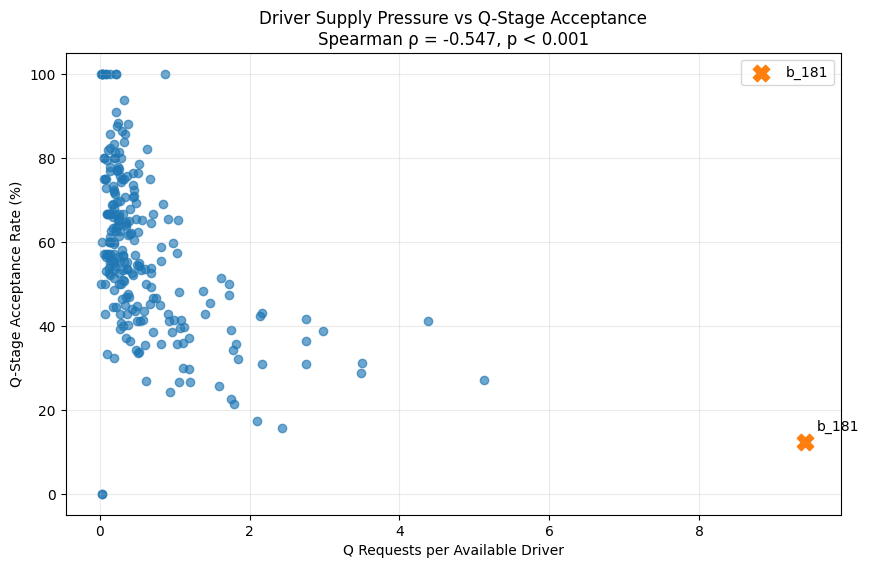

In [78]:
# ============================================================
# Visualize strongest supply-pressure relationship
# ============================================================

import matplotlib.pyplot as plt

plot_df = supply_demand_valid[
    [
        "ward_num",
        "q_requests_per_available_driver",
        "q_accept_rate"
    ]
].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["q_requests_per_available_driver"],
    plot_df["q_accept_rate"],
    alpha=0.65
)

# Highlight b_181
b181 = plot_df[plot_df["ward_num"] == "b_181"]

if not b181.empty:
    plt.scatter(
        b181["q_requests_per_available_driver"],
        b181["q_accept_rate"],
        s=140,
        marker="X",
        label="b_181"
    )

    plt.annotate(
        "b_181",
        (
            b181["q_requests_per_available_driver"].iloc[0],
            b181["q_accept_rate"].iloc[0]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Q Requests per Available Driver")
plt.ylabel("Q-Stage Acceptance Rate (%)")
plt.title(
    "Driver Supply Pressure vs Q-Stage Acceptance\n"
    "Spearman ρ = -0.547, p < 0.001"
)

plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [79]:
# ============================================================
# Q-stage performance by supply-pressure quartile
# ============================================================

pressure_quartile_df = supply_demand_valid[
    [
        "ward_num",
        "q_requests_per_available_driver",
        "q_accept_rate"
    ]
].dropna().copy()

pressure_quartile_df["pressure_quartile"] = pd.qcut(
    pressure_quartile_df["q_requests_per_available_driver"],
    q=4,
    labels=[
        "Q1 - Lowest Pressure",
        "Q2",
        "Q3",
        "Q4 - Highest Pressure"
    ]
)

pressure_quartile_summary = (
    pressure_quartile_df
    .groupby(
        "pressure_quartile",
        observed=True
    )
    .agg(
        wards=("ward_num", "count"),
        median_q_pressure=(
            "q_requests_per_available_driver",
            "median"
        ),
        median_q_acceptance=(
            "q_accept_rate",
            "median"
        )
    )
    .reset_index()
)

display(
    pressure_quartile_summary.round(2)
)

,pressure_quartile,wards,median_q_pressure,median_q_acceptance
0,Q1 - Lowest Pressure,61,0.11,63.16
1,Q2,60,0.25,66.29
2,Q3,60,0.45,54.77
3,Q4 - Highest Pressure,60,1.15,40.38


Wards in the highest-pressure quartile have substantially lower Q-stage acceptance than low-pressure wards.

### 8.5.2 Pressure-Quartile Interpretation

The quartile analysis reinforces the negative relationship between driver-supply pressure and Q-stage acceptance.

The two lower-pressure groups maintain median Q-stage acceptance above 63%, while acceptance falls to 54.77% in the third quartile and only 40.38% in the highest-pressure quartile.

The pattern is not perfectly monotonic because Q2 slightly exceeds Q1; however, the highest-pressure wards clearly perform substantially worse than the lower-pressure groups.

Median Q-stage acceptance in the highest-pressure quartile is approximately 22.8 percentage points lower than in the lowest-pressure quartile.

Combined with the Spearman correlation (`ρ = -0.547`, `p < 0.001`), this provides consistent evidence that increasing demand pressure on available drivers is associated with deterioration in Q-stage matching/acceptance performance.

## 8.6 Driver-Supply Analysis — Final Conclusion

Driver supply is not uniformly distributed relative to demand across Bangalore wards.

High-demand, low-conversion opportunity wards experience substantially greater pressure on available drivers than non-opportunity wards. Their median searches per available driver is 1.79 compared with 0.46, while median Q requests per available driver is 1.19 compared with 0.28.

Among the 35 opportunity wards:

- 13 show strong supply pressure,
- 16 show moderate supply pressure,
- 6 show no clear supply pressure.

Therefore, 29 of the 35 opportunity wards (82.9%) exhibit at least one meaningful supply-pressure signal.

Statistical analysis confirms that supply pressure is particularly relevant to the Q-stage. Q requests per available driver have a moderate negative association with Q-stage acceptance (`ρ = -0.547`, `p < 0.001`), while searches per available driver show a similar relationship (`ρ = -0.519`, `p < 0.001`).

However, supply indicators have little direct relationship with final conversion, suggesting that downstream funnel behaviour is influenced by additional mechanisms beyond driver availability alone.

Ward `b_181` represents the strongest combined supply-and-funnel problem, with extremely high demand pressure, low driver availability, high utilization, poor Q-stage acceptance, and the largest estimated booking opportunity gap.

In contrast, wards such as `w_0` show substantial booking opportunity despite abundant driver availability and very low utilization, demonstrating that increasing supply is not an appropriate intervention for every low-conversion ward.

The operational implication for NammaFlow is therefore to distinguish between:

1. **Supply-constrained wards** — requiring driver repositioning, supply incentives, or availability intervention.
2. **Matching-constrained wards** — requiring investigation of Q-stage matching or acceptance.
3. **Downstream-conversion wards** — requiring investigation of booking, cancellation, pricing, or ride-completion behaviour.

This segmentation provides the foundation for the decision-support and recommendation components developed in later phases.

# 9. Phase 2 — Exploratory Data Analysis Executive Summary

Phase 2 transformed the cleaned Namma Yatri operational datasets into a set of city-level, temporal, funnel, geographic, and driver-supply insights.

The objective was not only to describe ride activity, but to identify where operational inefficiencies occur and determine which problems could later be addressed through predictive modelling and decision-support logic.

## Key Findings

### 1. Ward-Level Opportunity

Using the 75th percentile of search demand (117.75 searches) and the median ward conversion rate (33.33%) as benchmarks, 35 wards were identified as high-demand, low-conversion opportunity zones.

Together, these wards represent an estimated recovery opportunity of approximately 2,443 additional bookings if their conversion performance were raised to the median ward benchmark.

The largest opportunities are concentrated in:

- `b_181` — approximately 1,065 bookings
- `w_0` — approximately 377 bookings
- `b_187` — approximately 185 bookings
- `b_131` — approximately 103 bookings
- `b_178` — approximately 94 bookings

### 2. Funnel Bottlenecks

Ward-level funnel decomposition shows that low conversion does not arise from the same stage in every ward.

For example, `b_181` successfully moves nearly all searches into the E-stage and most E-stage searches into Q-stage demand, but only 12.38% succeed at the Q-stage. Once Q-stage success occurs, booking conversion is extremely high.

This identifies the Q-stage as the dominant bottleneck for this ward.

### 3. Driver Supply and Demand Pressure

Opportunity wards experience substantially greater demand pressure than other wards.

Median searches per available driver are 1.79 among opportunity wards compared with 0.46 among non-opportunity wards.

Median Q-stage requests per available driver are 1.19 compared with only 0.28.

Opportunity wards also exhibit lower driver availability and higher driver utilization.

### 4. Supply-Pressure Classification

Among the 35 opportunity wards:

- 13 show strong supply pressure,
- 16 show moderate supply pressure,
- 6 show no clear supply pressure.

This demonstrates that driver shortages contribute to many low-conversion areas, but they do not explain every opportunity ward.

### 5. Statistical Evidence

Driver-supply pressure is moderately associated with Q-stage acceptance.

Q requests per available driver show a Spearman correlation of approximately -0.547 with Q-stage acceptance (`p < 0.001`).

Searches per available driver show a similar relationship of approximately -0.519 (`p < 0.001`).

The highest-pressure quartile records median Q-stage acceptance of only 40.38%, compared with 63.16% in the lowest-pressure quartile.

However, supply metrics have very weak relationships with final conversion, indicating that later funnel stages depend on additional operational factors.

### 6. Key Operational Case — `b_181`

`b_181` is the strongest identified intervention candidate:

- 4,862 searches
- 11.44% conversion
- 12.38% Q-stage acceptance
- 686 active drivers
- 480 available drivers
- 69.97% driver availability
- 30.03% on-ride utilization
- 10.13 searches per available driver
- 9.42 Q requests per available driver
- approximately 1,065 recoverable booking opportunities

The ward therefore combines extreme demand pressure with a severe Q-stage bottleneck.

### 7. Decision-Support Implication

The analysis indicates that NammaFlow should not apply one intervention to every low-performing ward.

Instead, wards should be diagnosed separately as:

- supply-constrained,
- matching-constrained,
- downstream-conversion constrained,
- or relatively healthy.

These findings provide the analytical foundation for feature engineering, machine-learning models, ward segmentation, supply-demand intelligence, and the final NammaFlow recommendation engine.

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
